# Composer Classification from MIDI Files Using Deep Learning

## Final Team Project – Group 6

### Team Members
1. Marston Ward
2. Josue Sandoval
3. Saman Tavasoli

---

## Project Overview

Music composer classification is a multiclass classification problem that aims to identify the composer of a musical piece based on patterns extracted from MIDI data. In this project, we develop deep learning models to classify classical music compositions from MIDI files. The project includes data exploration, MIDI preprocessing, feature extraction, model development, training, evaluation, and performance comparison using PyTorch.

---

## Project Objective

The main goal of this project is to develop deep learning models that can accurately predict the composer of a classical music piece represented as a MIDI file.

To accomplish this objective, we compare two deep learning architectures:

1. **Long Short-Term Memory (LSTM)** : designed to learn sequential patterns from musical note sequences.
2. **Convolutional Neural Network (CNN)** : designed to learn structured musical patterns from processed MIDI representations.

The performance of both models is evaluated using multiple classification metrics, including:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Finally, the two models are compared to determine which architecture performs better for composer classification.

---

## Dataset Description

The dataset used in this project is the **MIDI Classic Music** dataset obtained from Kaggle. It contains MIDI files from several well-known classical composers.

For this project, we only use MIDI files from the following four composers:

- Bach
- Beethoven
- Chopin
- Mozart

Each MIDI file is labeled with its corresponding composer, and these labels are used as the target classes for supervised learning.

---

## Project Workflow

The project is completed through the following steps:

1. Project Title
2. Import Libraries and Set Random Seed
3. Load and Explore Dataset
4. MIDI Preprocessing
5. Feature Extraction
6. Create Dataset Arrays and Normalize Features
7. Create PyTorch Dataset and DataLoaders
8. Build, Train, and Validate LSTM Model
9. Build, Train, and Validate CNN Model
10. Hyperparameter Tuning and Model Optimization
11. Final Model Evaluation and Comparison
12. Conclusions
13. References

---

**Tools and Frameworks**

This project is implemented in Python using PyTorch as the primary deep learning framework. Additional libraries are used for MIDI processing, data analysis, visualization, and model evaluation.

---

## 2. Import Libraries and Set Random Seed

In this section, we import all the Python libraries required throughout the project. These libraries are used for file management, data manipulation, visualization, MIDI processing, machine learning, and deep learning. We also set a fixed random seed to improve the reproducibility of our experiments. Using the same random seed helps produce more consistent results across different runs by reducing randomness during data splitting and model training.

In [1]:
from pathlib import Path
from copy import deepcopy
import time
import random
import json

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
import pretty_midi
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
# Set Random Seed
SEED = 511

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


cuda


---

## 3. Load and Explore Dataset (EDA)

In this section, we load, clean, organize, and explore the MIDI dataset before preprocessing and model development. The first part of the analysis examines the complete raw dataset to understand its structure, class distribution, and data-quality problems. Empty, corrupted, and exact duplicate MIDI files are identified and excluded.

After cleaning, the remaining files are divided into reproducible training, validation, and test sets using a stratified 70/15/15 split. The file-level assignments and dataset information are saved in manifest files so that the same split can be preserved throughout preprocessing, feature extraction, training, and evaluation. Detailed musical-feature analysis is performed using only the training set. This keeps the validation and test sets separate and reduces the risk of test information influencing feature or modeling decisions.

The EDA examines:

- Dataset folder structure
- Available composer labels
- Raw and cleaned MIDI file counts
- Class balance
- Empty, corrupted, and duplicate files
- Training, validation, and test distributions
- File duration, tempo, and track count
- Note count and note density
- Pitch, velocity, and note-duration characteristics
- Piano-roll representations
- Relationships among musical features
- Class separability using PCA
- Modeling implications identified from the EDA

Only the following four composers are included:

- Bach
- Beethoven
- Chopin
- Mozart

The EDA is organized into the following steps:

- **3.1** Define Project Paths
- **3.2** Verify Dataset Structure
- **3.3** Count MIDI Files
- **3.4** Visualize the Raw Dataset Distribution
- **3.5** Check Dataset Integrity
- **3.6** Create the Clean Dataset Split
  - **3.6.1** Visualize the Dataset Split
  - **3.6.2** Save the Dataset Manifest
- **3.7** Extract MIDI Metadata
- **3.8** Analyze Musical Features
- **3.9** Visualize Musical Feature Distributions
- **3.10** Analyze Pitch Characteristics
- **3.11** Visualize Piano Rolls
- **3.12** Create the Composer Feature Heatmap
- **3.13** Examine Feature Correlations
- **3.14** Examine Class Separability Using PCA
- **3.15** Analyze Note-Duration Distributions
- **3.16** Summarize the EDA Findings

### 3.1 Define Project Paths

This section defines the project directories and dataset paths used throughout the notebook. The code automatically identifies the project root directory, allowing the notebook to be executed from either the project root directory or the `notebooks` folder. It also defines the paths to the raw dataset and the processed dataset, ensuring that all subsequent sections access the data consistently.

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "dataset" / "raw" / "midi-classic-music"
PROCESSED_DATA_DIR = PROJECT_ROOT / "dataset" / "processed"

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)

Project root: d:\AAI_511_Final_Project\music-composer-classification-pytorch
Raw data directory: d:\AAI_511_Final_Project\music-composer-classification-pytorch\dataset\raw\midi-classic-music
Processed data directory: d:\AAI_511_Final_Project\music-composer-classification-pytorch\dataset\processed


### 3.2 Verify Dataset Structure

Before exploring the dataset, we verify that the required composer folders exist in the expected dataset directory and that the folder hierarchy is correctly organized. This step confirms that the notebook is connected to the correct dataset and that all four composers (Bach, Beethoven, Chopin, and Mozart) are available before continuing with the exploratory data analysis.

In [3]:
composer_names = ["Bach", "Beethoven", "Chopin", "Mozart"]

print("Checking dataset Structure: \n")
for composer in composer_names:
    composer_dir = RAW_DATA_DIR / composer

    if composer_dir.exists() and composer_dir.is_dir():
        print(f"Found: {composer}")
    else:
        print(f"Missing: {composer}")

Checking dataset Structure: 

Found: Bach
Found: Beethoven
Found: Chopin
Found: Mozart


### 3.3 Count MIDI Files
- Count MIDI files for each composer
- Calculate the total number of MIDI files
- Display the results in a summary table

In this step, we count the number of MIDI files available for each composer. The search is performed recursively so that MIDI files stored in nested subfolders are also included. The resulting file counts provide an overview of the dataset size for each composer and help identify whether the dataset is balanced or imbalanced before further preprocessing and model development.

In [4]:
midi_extensions = {".mid", ".midi"}

composer_counts = {}

for composer in composer_names:
    composer_dir = RAW_DATA_DIR / composer
    
    # Search recursively to include files inside nested folders
    midi_files = [
        file_path
        for file_path in composer_dir.rglob("*")
        if file_path.is_file()
        and file_path.suffix.lower() in midi_extensions
        and not file_path.name.startswith("._")
    ]
    
    composer_counts[composer] = len(midi_files)
    
composer_counts_df = pd.DataFrame(
    composer_counts.items(),
    columns=["Composer", "MIDI File Count"]
)

total_midi_files = composer_counts_df["MIDI File Count"].sum()

display(composer_counts_df)
print(f"Total MIDI files: {total_midi_files}")

,Composer,MIDI File Count
0,Bach,1024
1,Beethoven,213
2,Chopin,136
3,Mozart,257


Total MIDI files: 1630


### 3.4 Visualize Dataset Distribution
- Create a bar chart of the composer distribution
- Assess class balance

To better understand the distribution of the dataset, we visualize the number of MIDI files available for each composer using a bar chart. This visualization provides a clear overview of the dataset distribution and helps identify whether some composers have substantially more MIDI files than others. Understanding class balance at this stage is important because an imbalanced dataset can influence model training and evaluation.

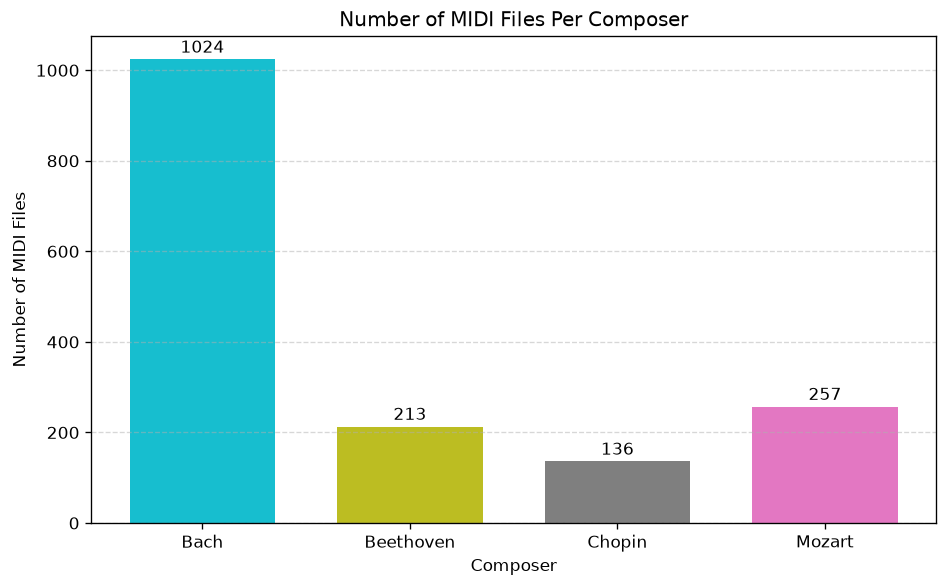

In [5]:
plt.figure(figsize=(8, 5), dpi=120)

plt.bar(
    composer_counts_df["Composer"],
    composer_counts_df["MIDI File Count"],
    color=plt.cm.tab10_r.colors,
    width=0.7
)

for i, value in enumerate(composer_counts_df["MIDI File Count"]):
    plt.text(i,value + 15,str(value),ha="center",fontsize=10)

plt.title("Number of MIDI Files Per Composer")
plt.xlabel("Composer")
plt.ylabel("Number of MIDI Files")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### 3.5 Check Dataset Integrity
- Detect empty MIDI files
- Detect corrupted MIDI files
- Detect exact duplicate MIDI files
- Summarize dataset integrity

Before preprocessing the dataset, we examine the MIDI files for potential data quality issues. Specifically, we check for empty files, corrupted or unreadable MIDI files, and exact duplicate files. Identifying these issues helps ensure that only valid and unique MIDI files are used during preprocessing, feature extraction, and model development, resulting in a more reliable dataset.

In [6]:
empty_files = []
corrupted_files = []
duplicate_files = []


# Storing file hashes to identify exact duplicates
file_hashes = {}

for composer in composer_names:
    composer_dir = RAW_DATA_DIR / composer
    
    midi_files = [
        file_path
        for file_path in composer_dir.rglob("*")
        if file_path.is_file()
        and file_path.suffix.lower() in midi_extensions
        and not file_path.name.startswith("._")
    ]
    
    for file_path in midi_files:
        
        if file_path.stat().st_size == 0:
            empty_files.append(file_path)
            continue
        
        # check whether the MIDI file can be parsed
        try:
            pretty_midi.PrettyMIDI(str(file_path))
        except Exception as error:
            corrupted_files.append((file_path, str(error)))
            continue
        
        # Create a hash to detect exact duplicate files
        with open(file_path, "rb") as midi_file:
            file_hash = hashlib.md5(midi_file.read()).hexdigest()
            
        if file_hash in file_hashes:
            duplicate_files.append(
                (file_path, file_hashes[file_hash])
            )
        else:
            file_hashes[file_hash] = file_path
            
print(f"Empty MIDI files: {len(empty_files)}")
print(f"Corrupted MIDI files: {len(corrupted_files)}")
print(f"Exact duplicates MIDI files : {len(duplicate_files)}")
    

d:\AAI_511_Final_Project\music-composer-classification-pytorch\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Empty MIDI files: 0
Corrupted MIDI files: 2
Exact duplicates MIDI files : 20


In [7]:
if corrupted_files:
    print("Corrupted MIDI files:")
    
    for file_path, error_message in corrupted_files:
        relative_path = file_path.relative_to(RAW_DATA_DIR)
        print(f"- {relative_path}")
        print(f" Error: {error_message}")
        
else: 
    print("No corrupted MIDI files were found.")
        
if duplicate_files:
    print("\nExact duplicate MIDI file pairs:")
    
    for duplicate_path, original_path in duplicate_files:
        duplicate_relative = duplicate_path.relative_to(RAW_DATA_DIR)
        original_relative = original_path.relative_to(RAW_DATA_DIR)
        
        print(f"- Duplicate: {duplicate_relative}")
        print(f" Original: {original_relative}")
        
else:
    print("\nNo exact duplicate MIDI files were found.")

Corrupted MIDI files:
- Beethoven\Anhang 14-3.mid
 Error: Could not decode key with 3 flats and mode 255
- Mozart\Piano Sonatas\Nueva carpeta\K281 Piano Sonata n03 3mov.mid
 Error: Could not decode key with 2 flats and mode 2

Exact duplicate MIDI file pairs:
- Duplicate: Bach\Piano version of Bachs two part inventions No.3.mid
 Original: Bach\Piano version of Bachs two part inventions No...mid
- Duplicate: Bach\Bwv001- 400 Chorales\007514b_.mid
 Original: Bach\Bwv001- 400 Chorales\007507b_.mid
- Duplicate: Bach\Bwv001- 400 Chorales\007614b_.mid
 Original: Bach\Bwv001- 400 Chorales\007607b_.mid
- Duplicate: Bach\Bwv001- 400 Chorales\014710b_.mid
 Original: Bach\Bwv001- 400 Chorales\014706b_.mid
- Duplicate: Bach\Bwv001- 400 Chorales\017507b_.mid
 Original: Bach\Bwv001- 400 Chorales\005903b_.mid
- Duplicate: Bach\Bwv001- 400 Chorales\022711b_.mid
 Original: Bach\Bwv001- 400 Chorales\022701b_.mid
- Duplicate: Bach\Bwv001- 400 Chorales\024417bv.mid
 Original: Bach\Bwv001- 400 Chorales\024

In [8]:
print("\nDataset Integrity Summary")
print(f"Empty MIDI files : {len(empty_files)}")
print(f"Corrupted MIDI files : {len(corrupted_files)}")
print(f"Exact duplicate MIDI files : {len(duplicate_files)}")
print("\nThese files will be excluded during preprocessing to ensure data quality.")


Dataset Integrity Summary
Empty MIDI files : 0
Corrupted MIDI files : 2
Exact duplicate MIDI files : 20

These files will be excluded during preprocessing to ensure data quality.


### 3.6 Create the Clean Dataset Split

After identifying corrupted, empty, and duplicate files, the remaining MIDI files are divided into training, validation, and test sets. The split is performed at the MIDI-file level using stratification so that each composer has approximately the same class proportion across all three sets. A fixed random seed is used to make the split reproducible.

- Training set: 70%
- Validation set: 15%
- Test set: 15%

In [9]:
corrupted_file_paths = {
    file_path for file_path, _ in corrupted_files
}

duplicate_file_paths = {
    duplicate_path for duplicate_path, _ in duplicate_files
}

excluded_file_paths = (
    set(empty_files)
    | corrupted_file_paths
    | duplicate_file_paths
)

clean_file_records = []

for composer in composer_names:
    composer_dir = RAW_DATA_DIR / composer

    midi_files = sorted([
        file_path
        for file_path in composer_dir.rglob("*")
        if file_path.is_file()
        and file_path.suffix.lower() in midi_extensions
        and not file_path.name.startswith("._")
    ])

    for file_path in midi_files:
        if file_path not in excluded_file_paths:
            clean_file_records.append({
                "composer": composer,
                "file_path": file_path,
                "relative_path": str(
                    file_path.relative_to(RAW_DATA_DIR)
                )
            })

clean_files_df = pd.DataFrame(clean_file_records)

# 70% training and 30% temporary
train_files_df, temp_files_df = train_test_split(
    clean_files_df,
    test_size=0.30,
    stratify=clean_files_df["composer"],
    random_state=SEED
)

# Divide the temporary set equally
validation_files_df, test_files_df = train_test_split(
    temp_files_df,
    test_size=0.50,
    stratify=temp_files_df["composer"],
    random_state=SEED
)

# Assign the split name
train_files_df = train_files_df.copy()
validation_files_df = validation_files_df.copy()
test_files_df = test_files_df.copy()

train_files_df["split"] = "train"
validation_files_df["split"] = "validation"
test_files_df["split"] = "test"

# Combine all split assignments into one manifest
file_manifest_df = pd.concat(
    [
        train_files_df,
        validation_files_df,
        test_files_df
    ],
    ignore_index=True
)

# Display the split inventory
split_inventory = pd.crosstab(
    file_manifest_df["composer"],
    file_manifest_df["split"]
)

split_inventory = split_inventory.reindex(
    index=composer_names,
    columns=["train", "validation", "test"],
    fill_value=0
)

split_inventory["total"] = split_inventory.sum(axis=1)

print(f"Clean MIDI files: {len(file_manifest_df)}")
display(split_inventory)

Clean MIDI files: 1608


split,train,validation,test,total
composer,,,,
Bach,709,152,153,1014
Beethoven,146,31,31,208
Chopin,92,20,20,132
Mozart,178,38,38,254


#### 3.6.1 Visualize the Dataset Split

The following charts show the number of clean MIDI files for each composer in the training, validation, and test sets. The dataset remains imbalanced across all three sets, with Bach having the most files and Chopin having the fewest.

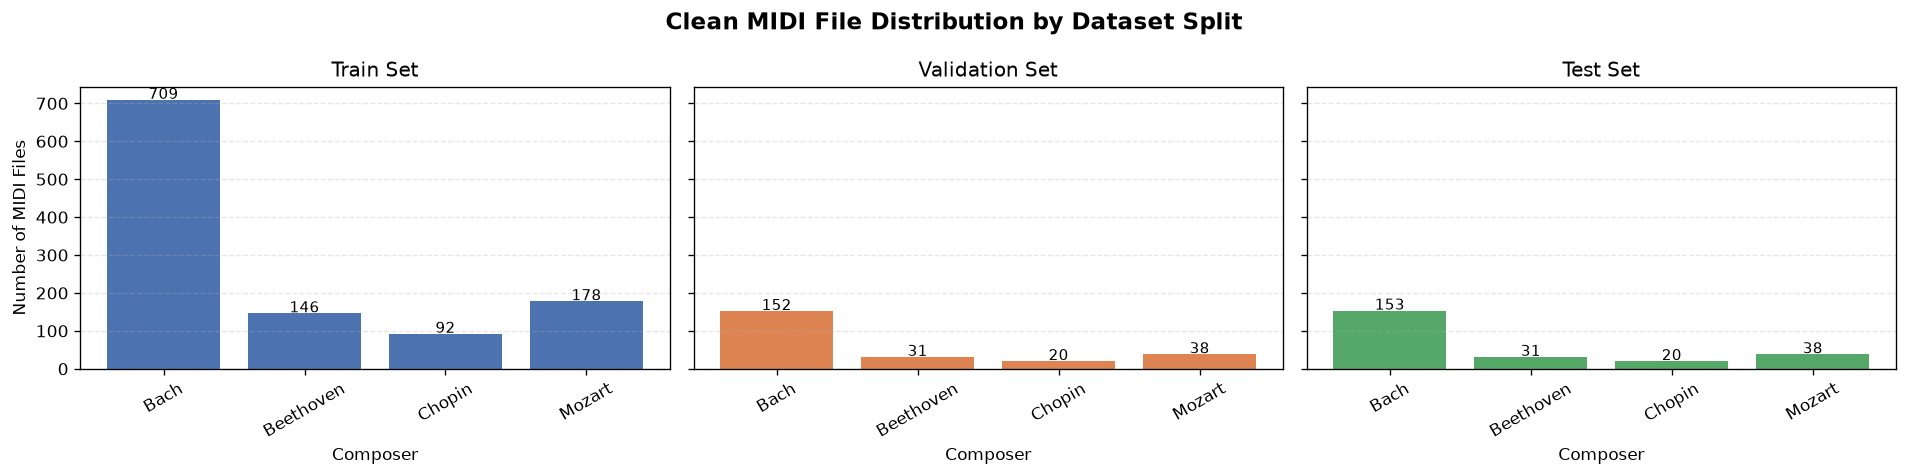

In [10]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4),
    sharey=True,
    dpi=120
)

split_names = ["train", "validation", "test"]

split_colors = {
    "train": "#4C72B0",
    "validation": "#DD8452",
    "test": "#55A868"
}

for ax, split_name in zip(axes, split_names):
    split_counts = split_inventory[split_name]

    bars = ax.bar(
        split_counts.index,
        split_counts.values,
        color=split_colors[split_name]
    )

    ax.set_title(f"{split_name.capitalize()} Set")
    ax.set_xlabel("Composer")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    if split_name == "train":
        ax.set_ylabel("Number of MIDI Files")

    for bar, count in zip(bars, split_counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3,
            str(count),
            ha="center",
            fontsize=9
        )

plt.suptitle(
    "Clean MIDI File Distribution by Dataset Split",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#### 3.6.2 Save the Dataset Manifest

To make the dataset preparation reproducible, the split assignments and dataset information are saved in manifest files. The JSON file records the dataset source, composers, random seed, split proportions, excluded-file counts, and split inventory. The CSV file records the assigned split for every clean MIDI file.

In [11]:
PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

manifest = {
    "source": (
        "https://www.kaggle.com/datasets/"
        "blanderbuss/midi-classic-music"
    ),
    "composers": composer_names,
    "seed": SEED,
    "split_proportions": {
        "train": 0.70,
        "validation": 0.15,
        "test": 0.15
    },
    "excluded_files": {
        "empty": len(empty_files),
        "corrupted": len(corrupted_files),
        "duplicates": len(duplicate_files)
    },
    "inventory": (
        split_inventory
        .astype(int)
        .to_dict(orient="index")
    )
}

json_manifest_path = (
    PROCESSED_DATA_DIR / "dataset_manifest.json"
)

with open(
    json_manifest_path,
    "w",
    encoding="utf-8"
) as manifest_file:
    json.dump(
        manifest,
        manifest_file,
        indent=4
    )

# Save the individual file assignments
split_manifest_df = (
    file_manifest_df[
        ["relative_path", "composer", "split"]
    ]
    .sort_values(
        ["split", "composer", "relative_path"]
    )
    .reset_index(drop=True)
)

csv_manifest_path = (
    PROCESSED_DATA_DIR / "dataset_split_manifest.csv"
)

split_manifest_df.to_csv(
    csv_manifest_path,
    index=False
)

print("JSON manifest saved to:")
print(json_manifest_path)

print("\nFile-level split manifest saved to:")
print(csv_manifest_path)

JSON manifest saved to:
d:\AAI_511_Final_Project\music-composer-classification-pytorch\dataset\processed\dataset_manifest.json

File-level split manifest saved to:
d:\AAI_511_Final_Project\music-composer-classification-pytorch\dataset\processed\dataset_split_manifest.csv


### 3.7 Extract MIDI Metadata

In this section, we extract musical metadata from every valid and unique MIDI file in the dataset. For each file, we collect:

- File size
- Duration
- Average tempo
- Number of tracks
- Number of notes
- Pitch statistics
- Mean velocity
- Mean note duration
- Note density

These features provide a more detailed understanding of the musical characteristics in the dataset and will support the later feature engineering, preprocessing, and model development stages.

In [12]:
midi_metadata = []
metadata_errors = []

for _, file_record in file_manifest_df.iterrows():

    composer = file_record["composer"]
    split = file_record["split"]
    file_path = file_record["file_path"]
    relative_path = file_record["relative_path"]

    try:
        midi_data = pretty_midi.PrettyMIDI(str(file_path))

        # Exclude drum tracks from musical note statistics
        all_notes = [
            note
            for instrument in midi_data.instruments
            if not instrument.is_drum
            for note in instrument.notes
        ]

        file_size_kb = file_path.stat().st_size / 1024
        duration_s = midi_data.get_end_time()
        n_tracks = len(midi_data.instruments)
        n_notes = len(all_notes)

        _, tempi = midi_data.get_tempo_changes()

        mean_tempo_bpm = (
            float(np.mean(tempi))
            if len(tempi) > 0
            else 120.0
        )

        if n_notes > 0:
            pitches = np.array([
                note.pitch for note in all_notes
            ])

            velocities = np.array([
                note.velocity for note in all_notes
            ])

            note_durations = np.array([
                note.end - note.start
                for note in all_notes
            ])

            mean_pitch = float(np.mean(pitches))
            min_pitch = int(np.min(pitches))
            max_pitch = int(np.max(pitches))
            pitch_range = max_pitch - min_pitch
            mean_velocity = float(np.mean(velocities))
            mean_note_duration_s = float(
                np.mean(note_durations)
            )

        else:
            mean_pitch = np.nan
            min_pitch = np.nan
            max_pitch = np.nan
            pitch_range = np.nan
            mean_velocity = np.nan
            mean_note_duration_s = np.nan

        note_density = (
            n_notes / duration_s
            if duration_s > 0
            else np.nan
        )

        midi_metadata.append({
            "split": split,
            "composer": composer,
            "file_name": file_path.name,
            "relative_path": relative_path,
            "file_size_kb": file_size_kb,
            "duration_s": duration_s,
            "mean_tempo_bpm": mean_tempo_bpm,
            "n_tracks": n_tracks,
            "n_notes": n_notes,
            "mean_pitch": mean_pitch,
            "min_pitch": min_pitch,
            "max_pitch": max_pitch,
            "pitch_range": pitch_range,
            "mean_velocity": mean_velocity,
            "mean_note_duration_s": mean_note_duration_s,
            "note_density": note_density
        })

    except Exception as error:
        metadata_errors.append({
            "file": relative_path,
            "error": str(error)
        })

midi_metadata_df = pd.DataFrame(midi_metadata)

print(f"Metadata records created: {len(midi_metadata_df)}")
print(f"Additional errors: {len(metadata_errors)}")

metadata_split_counts = pd.crosstab(
    midi_metadata_df["composer"],
    midi_metadata_df["split"]
)

metadata_split_counts = metadata_split_counts.reindex(
    index=composer_names,
    columns=["train", "validation", "test"],
    fill_value=0
)

display(metadata_split_counts)
display(midi_metadata_df.head())

d:\AAI_511_Final_Project\music-composer-classification-pytorch\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Metadata records created: 1608
Additional errors: 0


split,train,validation,test
composer,,,
Bach,709,152,153
Beethoven,146,31,31
Chopin,92,20,20
Mozart,178,38,38


,split,composer,file_name,relative_path,file_size_kb,duration_s,mean_tempo_bpm,n_tracks,n_notes,mean_pitch,min_pitch,max_pitch,pitch_range,mean_velocity,mean_note_duration_s,note_density
0,train,Bach,06. Chor Gratias Animus Tibi .mid,Bach\Bwv232 Mass\06. Chor Gratias Animus Tibi ...,25.610352,167.722836,95.444488,15,3035,64.032619,38,86,48,68.816804,0.669735,18.095330
1,train,Bach,009709b_.mid,Bach\Bwv001- 400 Chorales\009709b_.mid,3.656250,33.750000,96.000000,7,388,66.182990,46,86,40,96.000000,0.575064,11.496296
2,train,Beethoven,Hess074 Bagatella.mid,Beethoven\Hess074 Bagatella.mid,4.047852,41.523240,67.499995,2,534,58.689139,46,75,29,75.745318,0.306591,12.860268
3,train,Bach,041600b_.mid,Bach\Bwv001- 400 Chorales\041600b_.mid,2.059570,33.912996,92.000129,4,216,60.305556,41,77,36,96.000000,0.591787,6.369240
4,train,Mozart,Piano Concerto n26 K537 1mov ''Coronation''.mid,Mozart\Piano Concertos\Piano Concerto n26 K537...,82.821289,927.799220,115.514285,13,13208,66.443822,28,91,63,69.845321,0.310967,14.235839


### 3.8 Analyze Musical Features

Detailed musical-feature analysis is performed using only the training set. The validation and test sets remain separate so they can provide an unbiased evaluation of the deep learning models. The following statistics summarize duration, tempo, track count, note count, pitch, velocity, note duration, and note density. We first examine the overall training-set statistics and then compare the mean values for each composer.

In [13]:
train_metadata_df = midi_metadata_df[
    midi_metadata_df["split"] == "train"
].copy()

print(
    f"Training MIDI files used for EDA: "
    f"{len(train_metadata_df)}"
)

numerical_columns = [
    "duration_s",
    "mean_tempo_bpm",
    "n_tracks",
    "n_notes",
    "mean_pitch",
    "min_pitch",
    "max_pitch",
    "pitch_range",
    "mean_velocity",
    "mean_note_duration_s",
    "note_density"
]

feature_statistics = (
    train_metadata_df[numerical_columns]
    .describe()
    .round(2)
)

display(feature_statistics)

composer_feature_summary = (
    train_metadata_df
    .groupby("composer")
    .agg(
        Files=("file_name", "count"),
        Duration_mean_s=("duration_s", "mean"),
        Duration_std_s=("duration_s", "std"),
        Tempo_mean_bpm=("mean_tempo_bpm", "mean"),
        Tracks_mean=("n_tracks", "mean"),
        Notes_mean=("n_notes", "mean"),
        Note_density_mean=("note_density", "mean"),
        Mean_pitch=("mean_pitch", "mean"),
        Pitch_range_mean=("pitch_range", "mean"),
        Velocity_mean=("mean_velocity", "mean"),
        Note_duration_mean_s=(
            "mean_note_duration_s",
            "mean"
        )
    )
    .round(2)
)

print("\nMusical Feature Summary by Composer")
display(composer_feature_summary)

Training MIDI files used for EDA: 1125


,duration_s,mean_tempo_bpm,n_tracks,n_notes,mean_pitch,min_pitch,max_pitch,pitch_range,mean_velocity,mean_note_duration_s,note_density
count,1125.00,1125.00,1125.00,1125.00,1125.00,1125.00,1125.00,1125.00,1125.00,1125.00,1125.00
mean,251.47,97.76,5.26,3081.67,62.95,35.19,84.18,48.99,83.87,0.43,10.77
std,343.60,36.26,4.44,4554.68,2.98,6.33,6.98,11.90,18.55,0.20,7.28
min,17.50,24.94,1.00,83.00,52.61,9.00,70.00,21.00,33.05,0.10,0.60
25%,51.00,75.86,2.00,378.00,61.13,30.00,79.00,38.00,64.42,0.26,6.44
50%,132.00,96.00,4.00,1179.00,62.84,36.00,84.00,48.00,93.42,0.39,8.17
75%,334.24,112.88,6.00,3791.00,64.73,39.00,88.00,58.00,96.00,0.57,12.32
max,5209.31,290.00,37.00,33835.00,75.27,62.00,103.00,84.00,127.00,1.55,51.31



Musical Feature Summary by Composer


,Files,Duration_mean_s,Duration_std_s,Tempo_mean_bpm,Tracks_mean,Notes_mean,Note_density_mean,Mean_pitch,Pitch_range_mean,Velocity_mean,Note_duration_mean_s
composer,,,,,,,,,,,
Bach,709,159.89,269.70,89.71,4.75,1679.76,9.26,62.32,43.10,89.34,0.47
Beethoven,146,514.74,536.90,118.61,7.01,7342.22,14.05,63.64,61.08,74.36,0.34
Chopin,92,222.09,199.79,112.89,2.60,2497.12,11.55,62.92,62.99,67.40,0.35
Mozart,178,415.52,289.51,104.90,7.24,5473.22,13.69,64.86,55.31,78.41,0.34


### 3.9 Visualize Musical Feature Distributions

To better understand the extracted musical features, we visualize their distributions using histograms. The histograms illustrate the distribution of each numerical feature, including duration, tempo, number of tracks, number of notes, pitch statistics, note duration, velocity, and note density. These visualizations help identify the range, spread, skewness, and potential outliers of each feature before feature engineering and model development. All visualizations in this section use only the training set.

#### 3.9.1 Overall Feature Distributions

First, we examine the overall distributions of the extracted numerical features across all four composers. The histograms provide an overview of the shape, spread, skewness, and potential outliers of each musical feature without separating the files by composer.

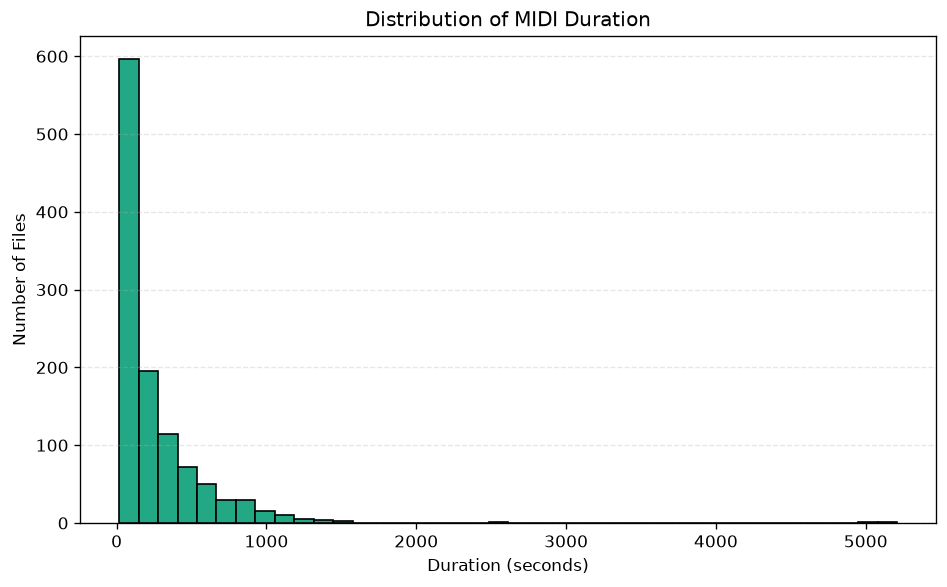

In [14]:
plt.figure(figsize=(8, 5), dpi=120)

plt.hist(
    train_metadata_df["duration_s"].dropna(),
    bins=40,
    color=plt.cm.viridis(0.6),
    edgecolor="black"
)

plt.title("Distribution of MIDI Duration")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Files")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

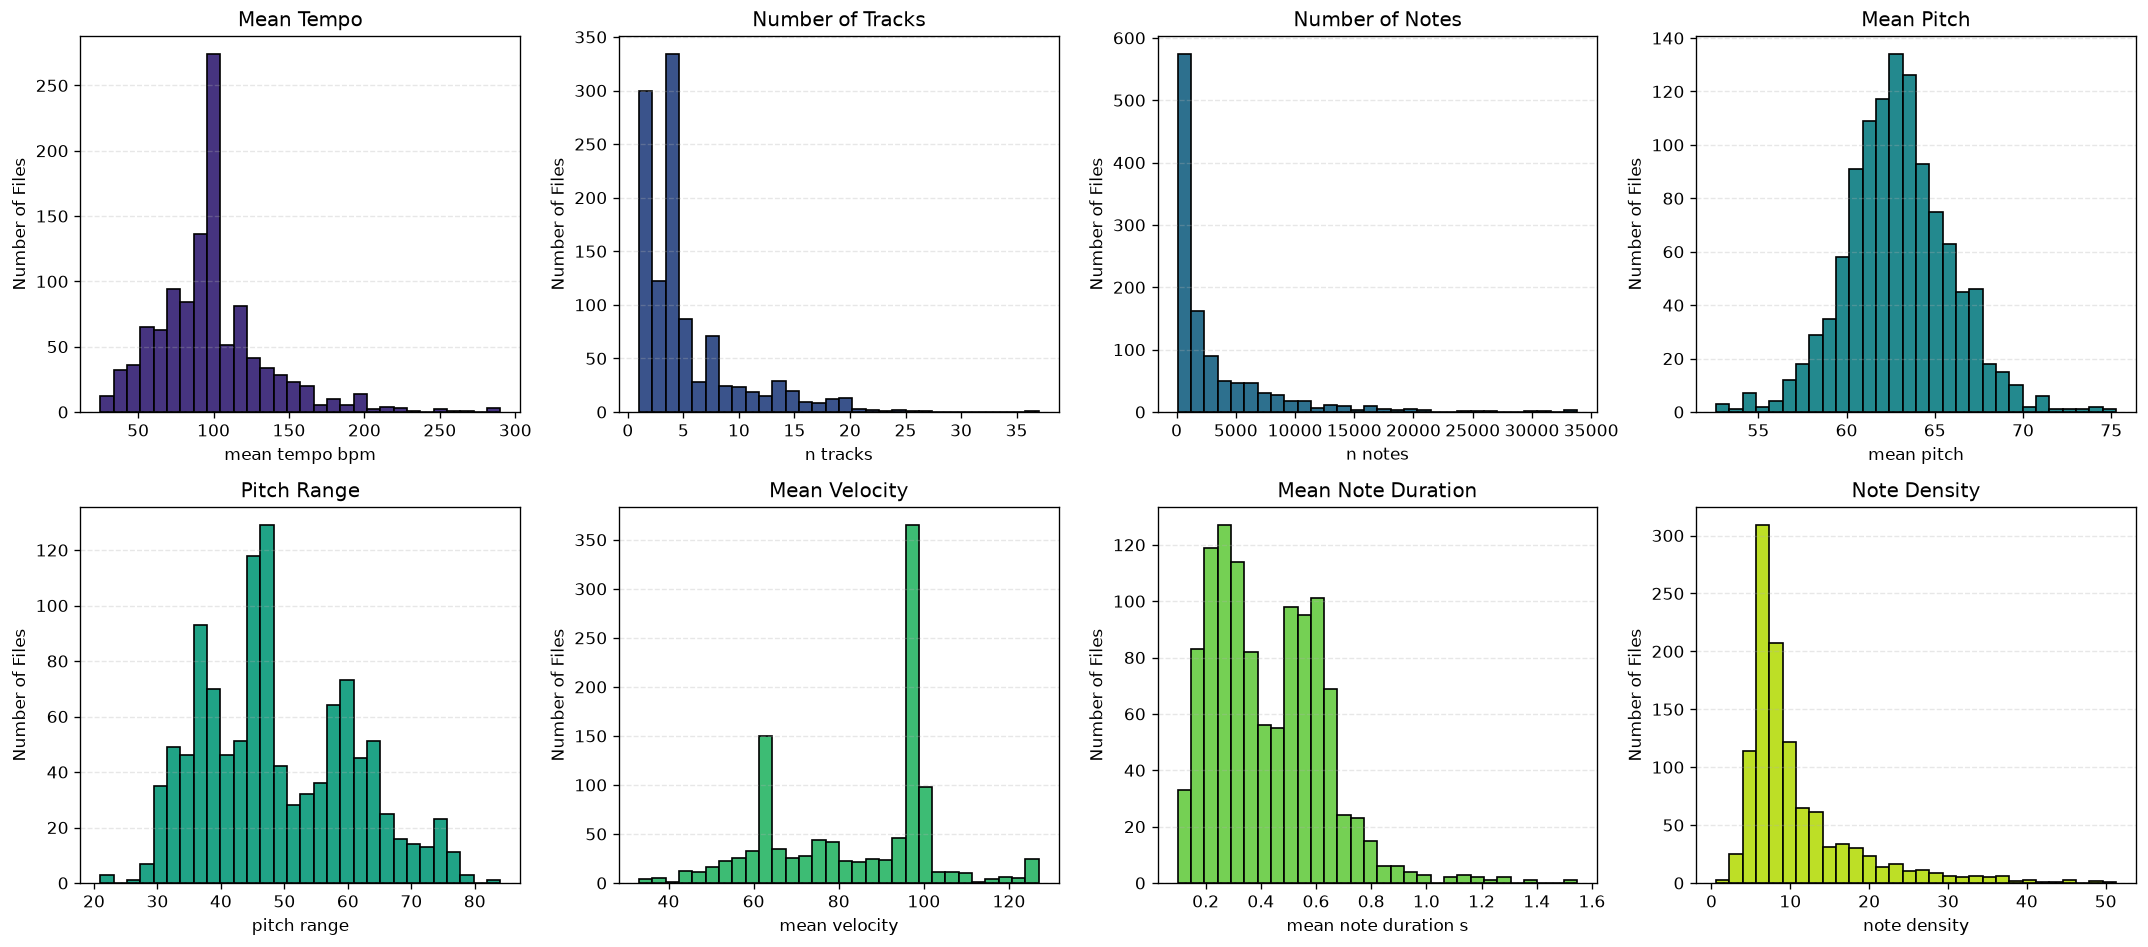

In [15]:
# Feature Distributions — Remaining Features
features = [
    "mean_tempo_bpm",
    "n_tracks",
    "n_notes",
    "mean_pitch",
    "pitch_range",
    "mean_velocity",
    "mean_note_duration_s",
    "note_density",
]

feature_titles = [
    "Mean Tempo",
    "Number of Tracks",
    "Number of Notes",
    "Mean Pitch",
    "Pitch Range",
    "Mean Velocity",
    "Mean Note Duration",
    "Note Density",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8), dpi=120)
colors = plt.cm.viridis(
    np.linspace(0.15, 0.9, len(features))
)

for ax, feature, title, color in zip(
    axes.flatten(),
    features,
    feature_titles,
    colors
):
    ax.hist(
        train_metadata_df[feature].dropna(),
        bins=30,
        color=color,
        edgecolor="black"
    )

    ax.set_title(title)
    ax.set_xlabel(feature.replace("_", " "))
    ax.set_ylabel("Number of Files")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

#### 3.9.2 Composer-wise Feature Comparisons

Here, we compare selected musical features across the four composers using boxplots. These comparisons help identify differences in duration, tempo, track count, note count, and note density among Bach, Beethoven, Chopin, and Mozart. Because some features contain extreme values, logarithmic scaling is used where appropriate to improve readability.

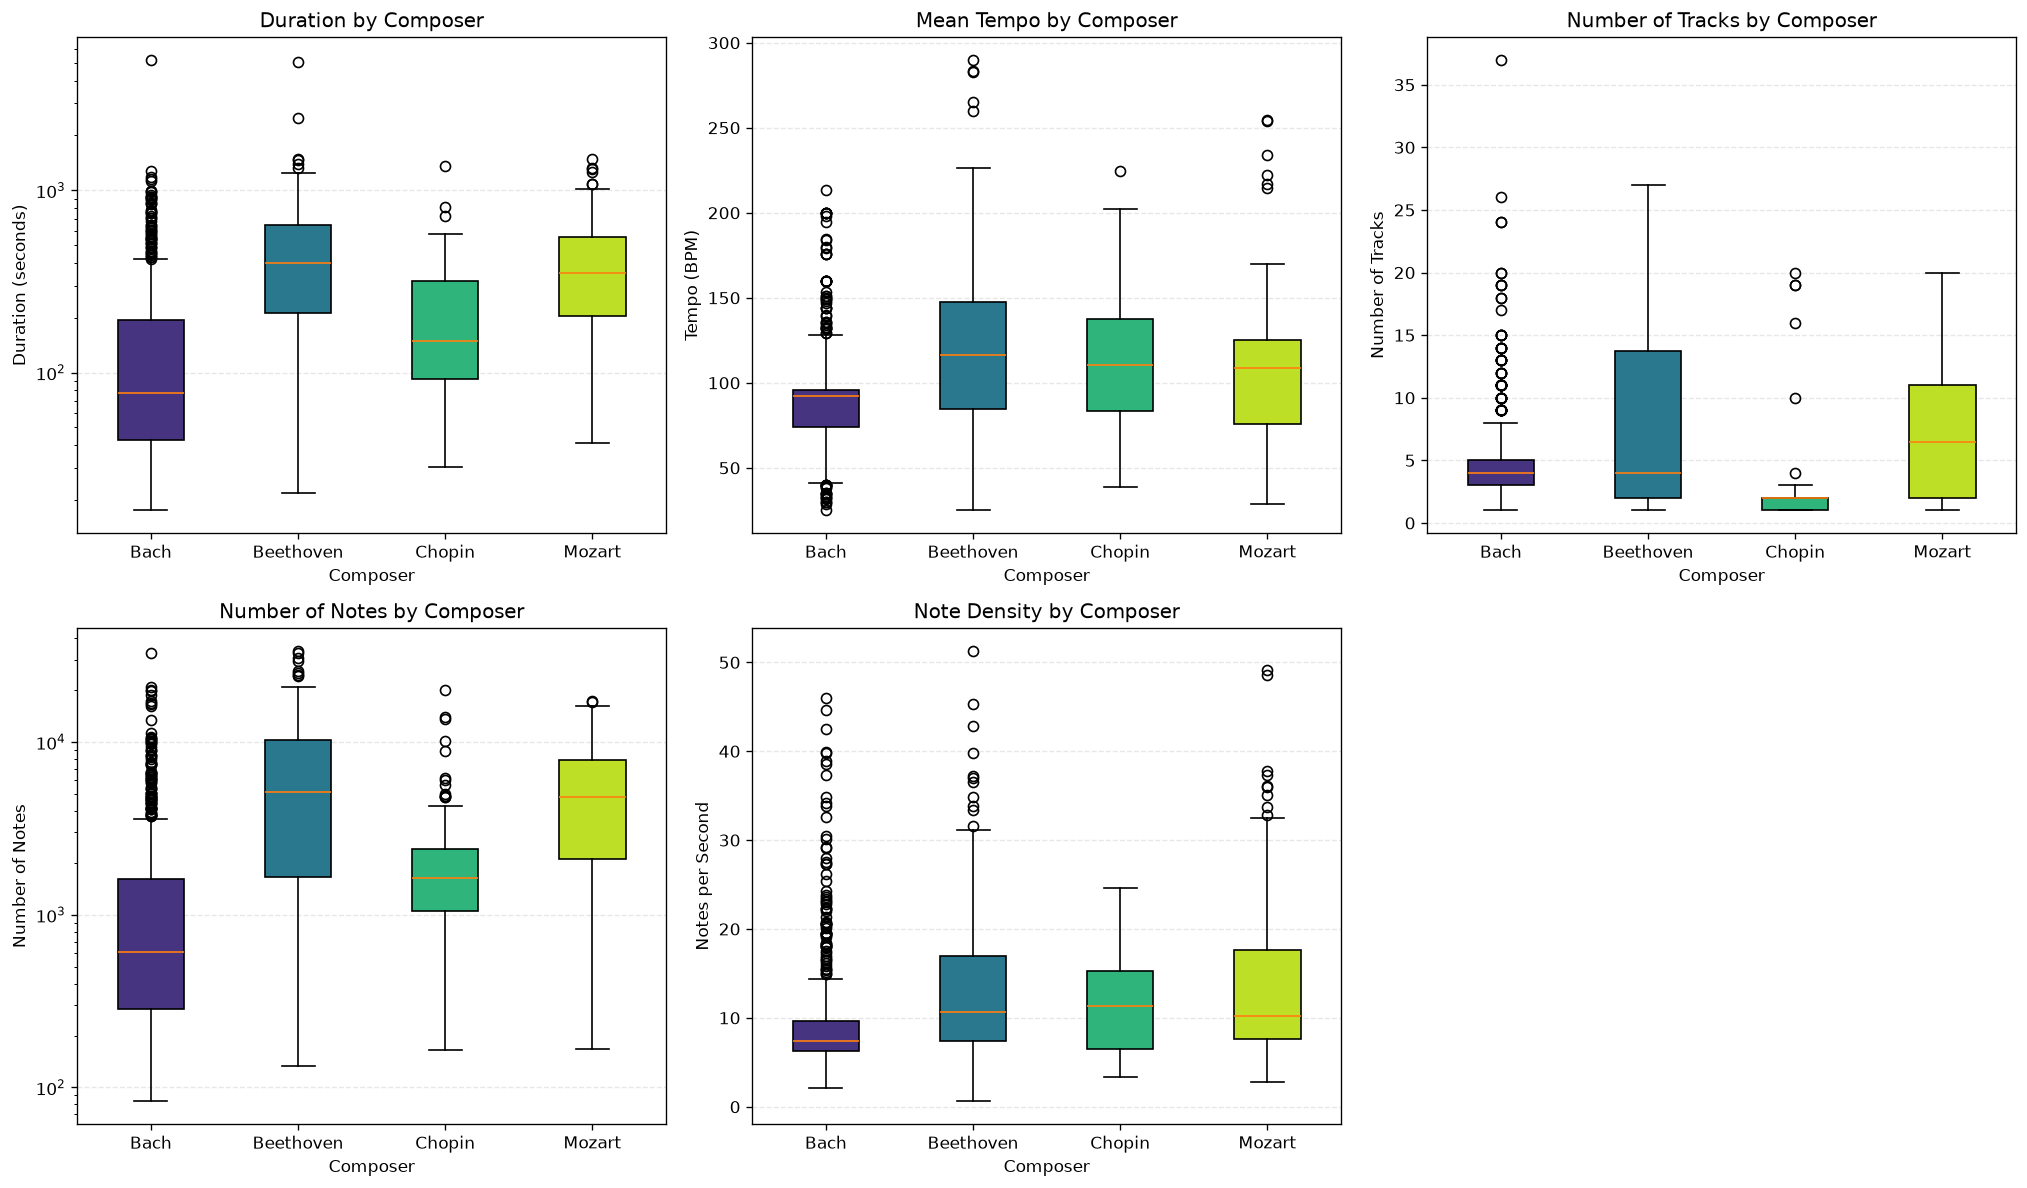

In [16]:
comparison_features = [
    ("duration_s", "Duration by Composer", "Duration (seconds)", True),
    ("mean_tempo_bpm", "Mean Tempo by Composer", "Tempo (BPM)", False),
    ("n_tracks", "Number of Tracks by Composer", "Number of Tracks", False),
    ("n_notes", "Number of Notes by Composer", "Number of Notes", True),
    ("note_density", "Note Density by Composer", "Notes per Second", False),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10), dpi=120)

plot_colors = plt.cm.viridis(
    np.linspace(0.15, 0.9, len(composer_names))
)

for ax, (feature, title, ylabel, use_log_scale) in zip(
    axes.flatten(),
    comparison_features
):
    composer_values = [
        train_metadata_df.loc[
            train_metadata_df["composer"] == composer,
            feature
        ].dropna()
        for composer in composer_names
    ]

    boxplot = ax.boxplot(
        composer_values,
        tick_labels=composer_names,
        patch_artist=True,
        showfliers=True
    )

    for box, color in zip(boxplot["boxes"], plot_colors):
        box.set_facecolor(color)

    ax.set_title(title)
    ax.set_xlabel("Composer")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    if use_log_scale:
        ax.set_yscale("log")

axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

### 3.10 Analyze Pitch Characteristics

- Visualize the overall mean-pitch distribution
- Compare mean pitch across composers
- Compare pitch range across composers

In this section, we examine the pitch characteristics of the training MIDI files. The overall pitch distribution shows the typical pitch values present in the dataset, while composer-wise comparisons help identify differences in average pitch and pitch range among Bach, Beethoven, Chopin, and Mozart. These characteristics may provide useful information for distinguishing composers during model development.

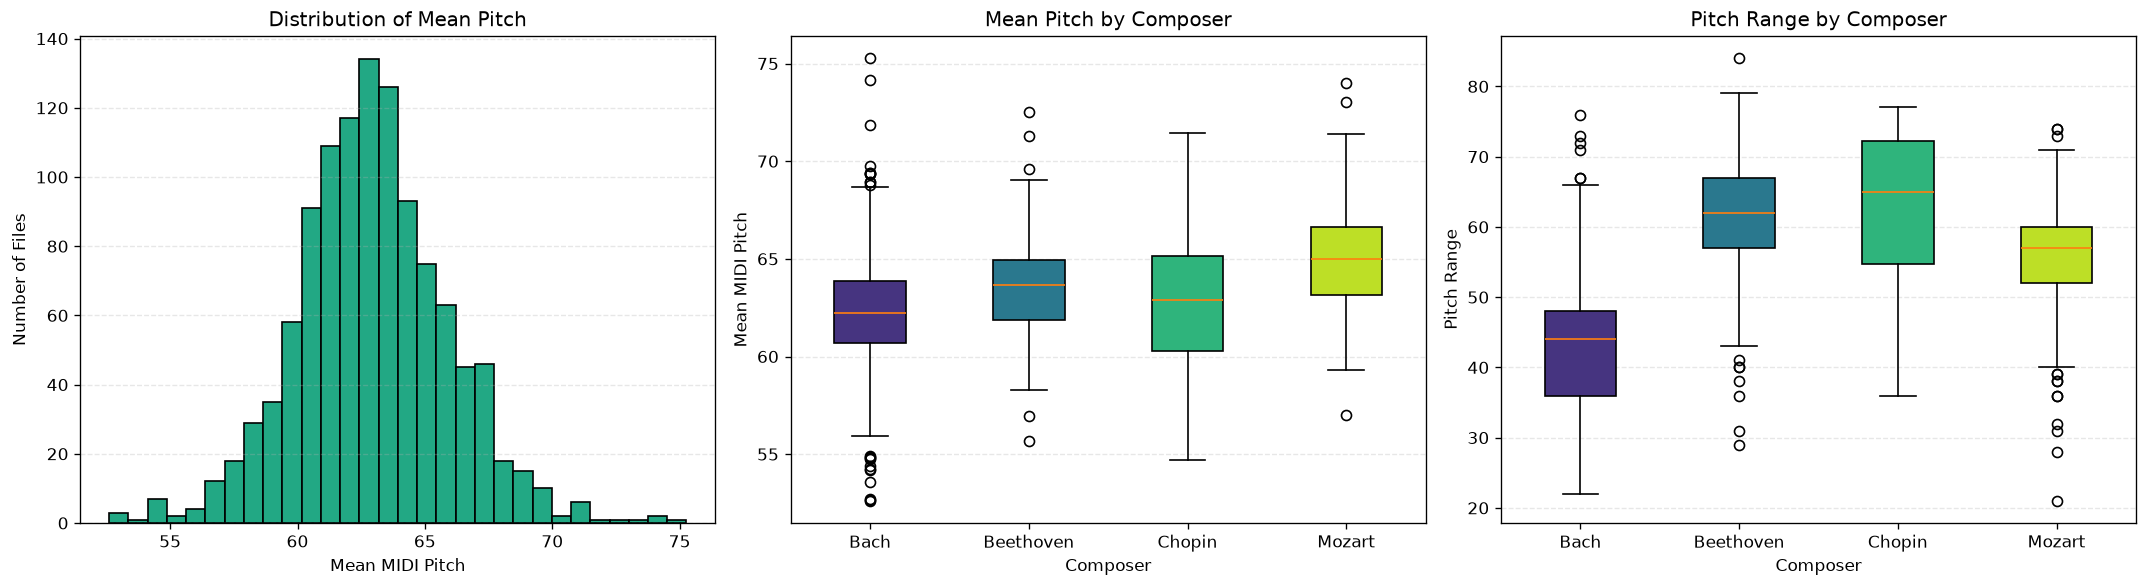

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

pitch_colors = plt.cm.viridis(
    np.linspace(0.15, 0.9, len(composer_names))
)

# Distribution of mean pitch
axes[0].hist(
    train_metadata_df["mean_pitch"].dropna(),
    bins=30,
    color=plt.cm.viridis(0.6),
    edgecolor="black"
)

axes[0].set_title("Distribution of Mean Pitch")
axes[0].set_xlabel("Mean MIDI Pitch")
axes[0].set_ylabel("Number of Files")
axes[0].grid(axis="y", linestyle="--", alpha=0.3)

# Prepare composer-wise pitch values
mean_pitch_values = [
    train_metadata_df.loc[
        train_metadata_df["composer"] == composer,
        "mean_pitch"
    ].dropna()
    for composer in composer_names
]

pitch_range_values = [
    train_metadata_df.loc[
        train_metadata_df["composer"] == composer,
        "pitch_range"
    ].dropna()
    for composer in composer_names
]

# Mean pitch comparison by composer
mean_pitch_boxplot = axes[1].boxplot(
    mean_pitch_values,
    tick_labels=composer_names,
    patch_artist=True,
    showfliers=True
)

for box, color in zip(mean_pitch_boxplot["boxes"], pitch_colors):
    box.set_facecolor(color)

axes[1].set_title("Mean Pitch by Composer")
axes[1].set_xlabel("Composer")
axes[1].set_ylabel("Mean MIDI Pitch")
axes[1].grid(axis="y", linestyle="--", alpha=0.3)

# Pitch range comparison by composer
pitch_range_boxplot = axes[2].boxplot(
    pitch_range_values,
    tick_labels=composer_names,
    patch_artist=True,
    showfliers=True
)

for box, color in zip(pitch_range_boxplot["boxes"], pitch_colors):
    box.set_facecolor(color)

axes[2].set_title("Pitch Range by Composer")
axes[2].set_xlabel("Composer")
axes[2].set_ylabel("Pitch Range")
axes[2].grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

#### 3.10.1 Per-Note Pitch Distribution by Composer

The previous plots summarize pitch at the MIDI-file level. In this analysis, all individual note pitches from the training files are combined for each composer. This provides a more detailed view of the pitch ranges and pitch frequencies commonly used by each composer. Drum tracks are excluded because they do not represent melodic MIDI pitches in the same way as other instruments.

d:\AAI_511_Final_Project\music-composer-classification-pytorch\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
d:\AAI_511_Final_Project\music-composer-classification-pytorch\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
d:\AAI_511_Final_Project\music-composer-classification-pytorch\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
d:\AAI_511_Final_Project\music-composer-classification-pyt

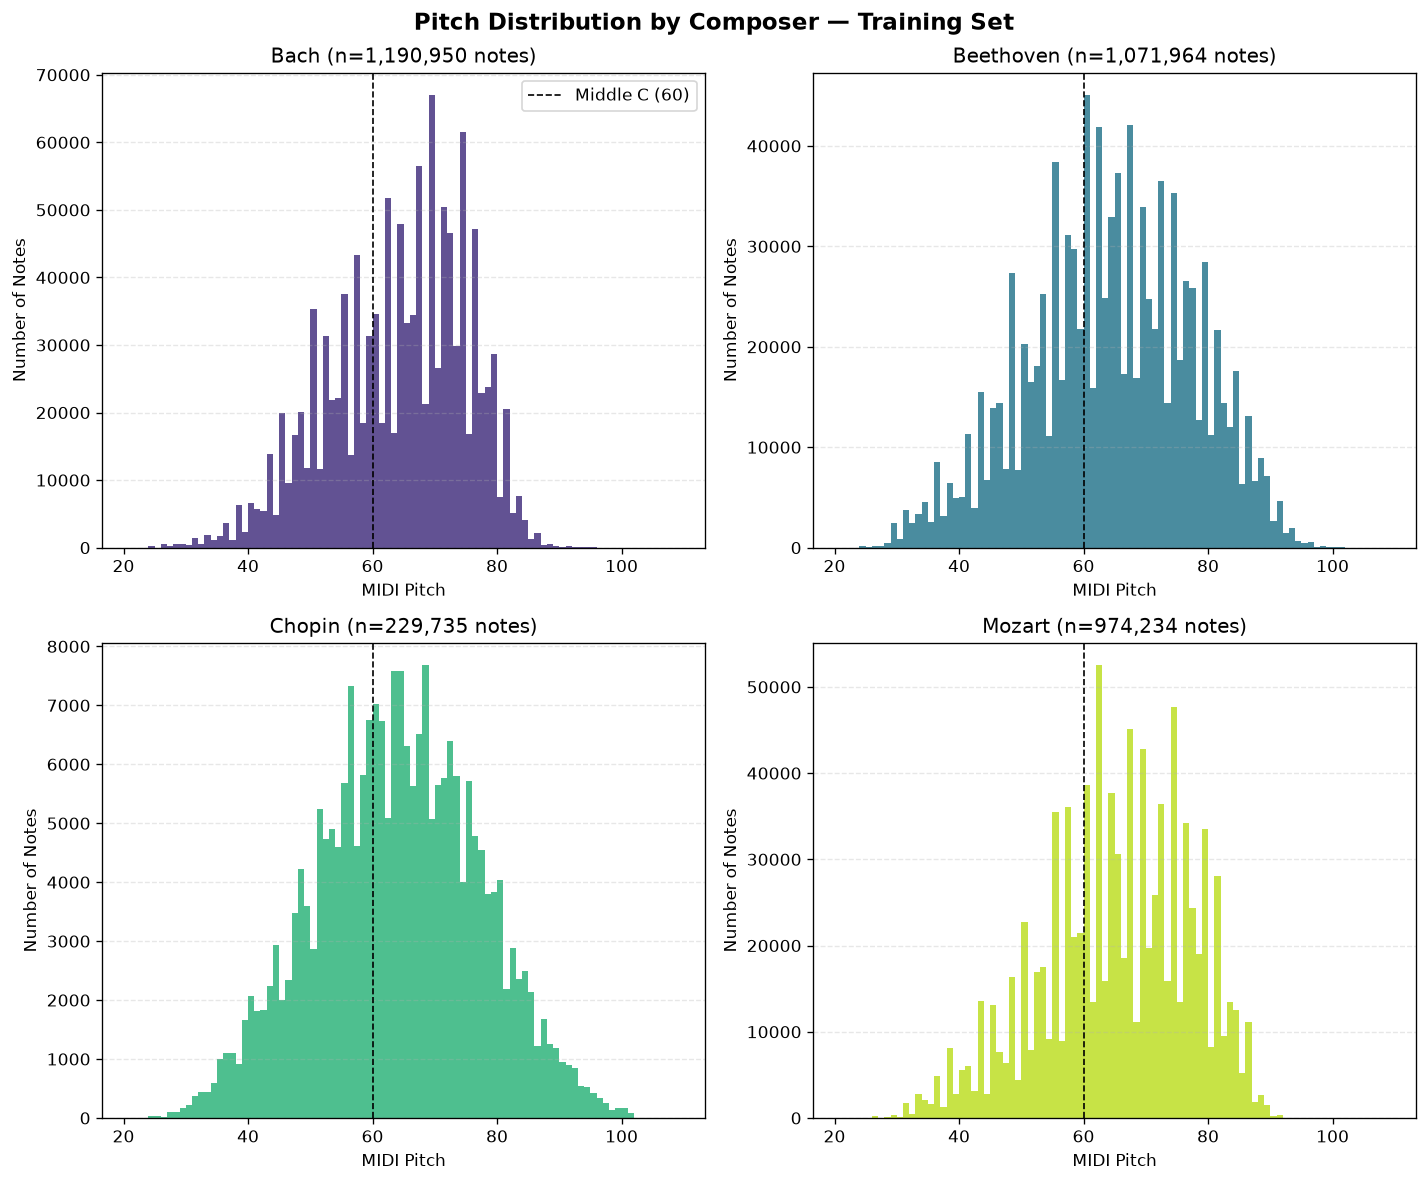

In [18]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10),
    dpi=120
)

axes = axes.flatten()
pitch_colors = plt.cm.viridis(
    np.linspace(0.15, 0.9, len(composer_names))
)

for index, composer in enumerate(composer_names):

    composer_files = train_metadata_df[
        train_metadata_df["composer"] == composer
    ]

    all_pitches = []

    for _, row in composer_files.iterrows():
        file_path = (
            RAW_DATA_DIR / row["relative_path"]
        )

        try:
            midi_data = pretty_midi.PrettyMIDI(
                str(file_path)
            )

            pitches = [
                note.pitch
                for instrument in midi_data.instruments
                if not instrument.is_drum
                for note in instrument.notes
            ]

            all_pitches.extend(pitches)

        except Exception:
            continue

    ax = axes[index]

    ax.hist(
        all_pitches,
        bins=88,
        range=(21, 109),
        color=pitch_colors[index],
        alpha=0.85
    )

    ax.axvline(
        60,
        color="black",
        linestyle="--",
        linewidth=1,
        label="Middle C (60)"
    )

    ax.set_title(
        f"{composer} (n={len(all_pitches):,} notes)"
    )

    ax.set_xlabel("MIDI Pitch")
    ax.set_ylabel("Number of Notes")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    if index == 0:
        ax.legend()

plt.suptitle(
    "Pitch Distribution by Composer — Training Set",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 3.11 Piano Roll Visualization 

Visualize the note sequences of representative MIDI files:
- Piano roll representation
- Time versus pitch
- Musical note patterns

A piano roll provides a visual representation of the notes contained in a MIDI file. The horizontal axis represents time, while the vertical axis represents MIDI pitch values.

By visualizing representative pieces from the dataset, we can better understand note density, pitch distribution, rhythmic patterns, and the overall musical structure of different composers. This also serves as a visual verification that the MIDI files have been parsed correctly before feature engineering and model development. The representative MIDI files are selected only from the training set.

d:\AAI_511_Final_Project\music-composer-classification-pytorch\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


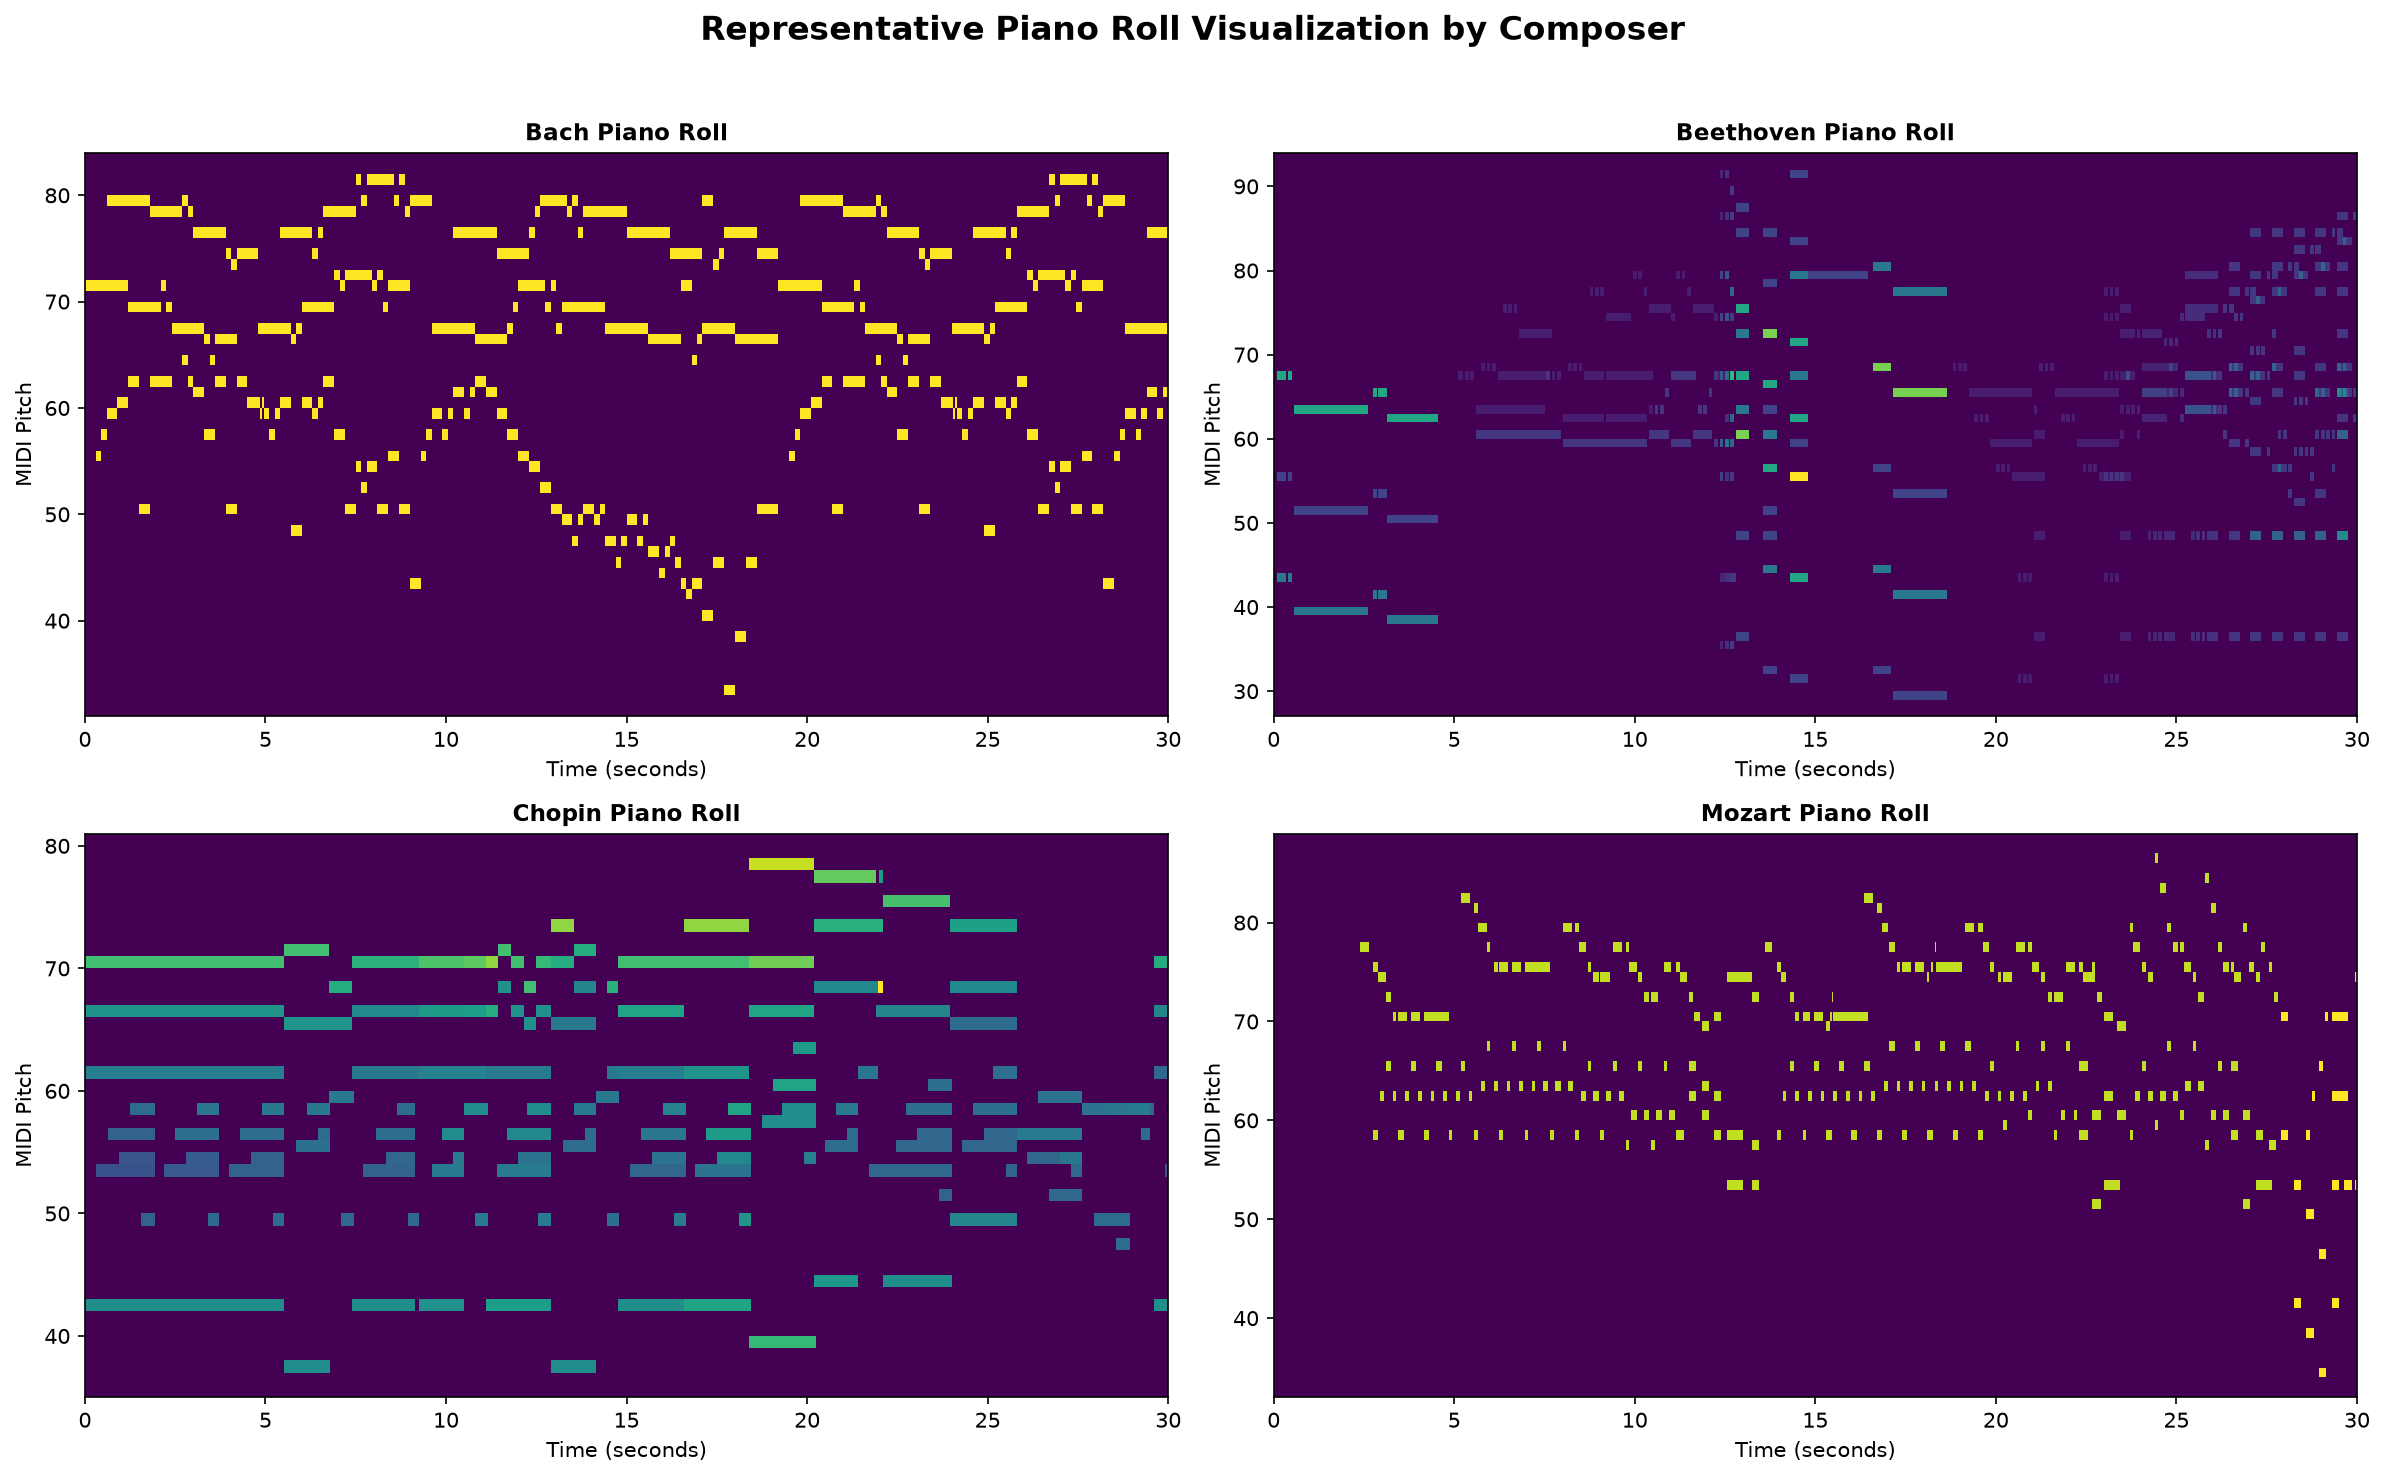

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=150)

display_duration_s = 30
piano_roll_fs = 20

for ax, composer in zip(axes.flatten(), composer_names):

    # Select a representative file near the median duration
    composer_data = (
        train_metadata_df[
            train_metadata_df["composer"] == composer
        ]
        .dropna(subset=["duration_s"])
        .copy()
    )

    median_duration = composer_data["duration_s"].median()

    representative_row = composer_data.loc[
        (composer_data["duration_s"] - median_duration)
        .abs()
        .idxmin()
    ]

    file_path = RAW_DATA_DIR / representative_row["relative_path"]

    midi_data = pretty_midi.PrettyMIDI(str(file_path))

    # Create the piano-roll matrix
    piano_roll = midi_data.get_piano_roll(fs=piano_roll_fs)

    end_frame = min(
        piano_roll.shape[1],
        display_duration_s * piano_roll_fs
    )

    piano_roll_segment = piano_roll[:, :end_frame]

    # Keep only the pitch range containing notes
    active_pitches = np.where(
        piano_roll_segment.max(axis=1) > 0
    )[0]

    if len(active_pitches) > 0:
        min_active_pitch = max(0, active_pitches.min() - 2)
        max_active_pitch = min(127, active_pitches.max() + 2)
    else:
        min_active_pitch = 0
        max_active_pitch = 127

    displayed_roll = piano_roll_segment[
        min_active_pitch:max_active_pitch + 1
    ]

    end_time = end_frame / piano_roll_fs

    ax.imshow(
        displayed_roll,
        aspect="auto",
        origin="lower",
        interpolation="nearest",
        cmap="viridis",
        extent=[
            0,
            end_time,
            min_active_pitch,
            max_active_pitch + 1
        ]
    )

    ax.set_title(
    f"{composer} Piano Roll",
    fontsize=11,
    fontweight="bold"
)
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("MIDI Pitch")

plt.suptitle(
    "Representative Piano Roll Visualization by Composer",
    fontsize=16,
    fontweight="bold"
)


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 3.12 Feature Heatmap by Composer

This heatmap compares the average musical-feature values of the four composers using the training set. Because the features use different measurement scales, their composer averages are normalized between 0 and 1 for the heatmap colors. The numbers displayed inside the cells show the original mean values before normalization.

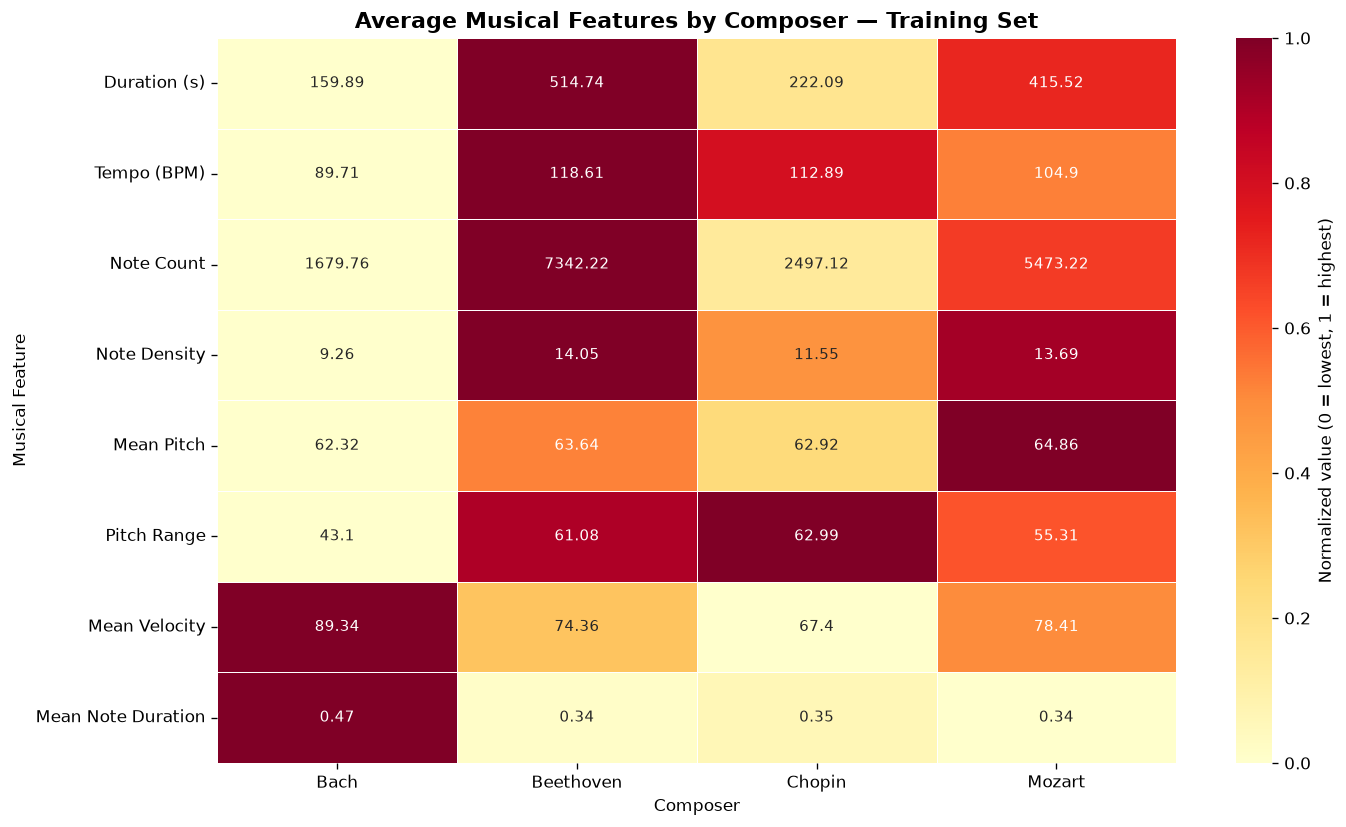

In [20]:
heatmap_features = [
    "duration_s",
    "mean_tempo_bpm",
    "n_notes",
    "note_density",
    "mean_pitch",
    "pitch_range",
    "mean_velocity",
    "mean_note_duration_s"
]

heatmap_labels = [
    "Duration (s)",
    "Tempo (BPM)",
    "Note Count",
    "Note Density",
    "Mean Pitch",
    "Pitch Range",
    "Mean Velocity",
    "Mean Note Duration"
]

composer_means = (
    train_metadata_df
    .groupby("composer")[heatmap_features]
    .mean()
)

# Normalizing each feature 
composer_normalized = (
    composer_means - composer_means.min()
) / (
    composer_means.max() - composer_means.min()
)

composer_means.columns = heatmap_labels
composer_normalized.columns = heatmap_labels

plt.figure(figsize=(12, 7), dpi=120)

sns.heatmap(
    composer_normalized.T,
    annot=composer_means.T.round(2),
    fmt="g",
    cmap="YlOrRd",
    linewidths=0.4,
    annot_kws={"size": 9},
    cbar_kws={
        "label": "Normalized value (0 = lowest, 1 = highest)"
    }
)

plt.title(
    "Average Musical Features by Composer — Training Set",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Composer")
plt.ylabel("Musical Feature")
plt.tight_layout()
plt.show()

### 3.13 Examine Feature Correlations

In this section, we examine the relationships among the extracted numerical musical features using a correlation matrix. The correlation heatmap illustrates the strength and direction of the relationships between pairs of features. Positive correlations indicate that two features tend to increase together, while negative correlations indicate an inverse relationship. Understanding these relationships provides useful insight into the dataset and can help guide feature selection and model development. Correlations are calculated using the training set.

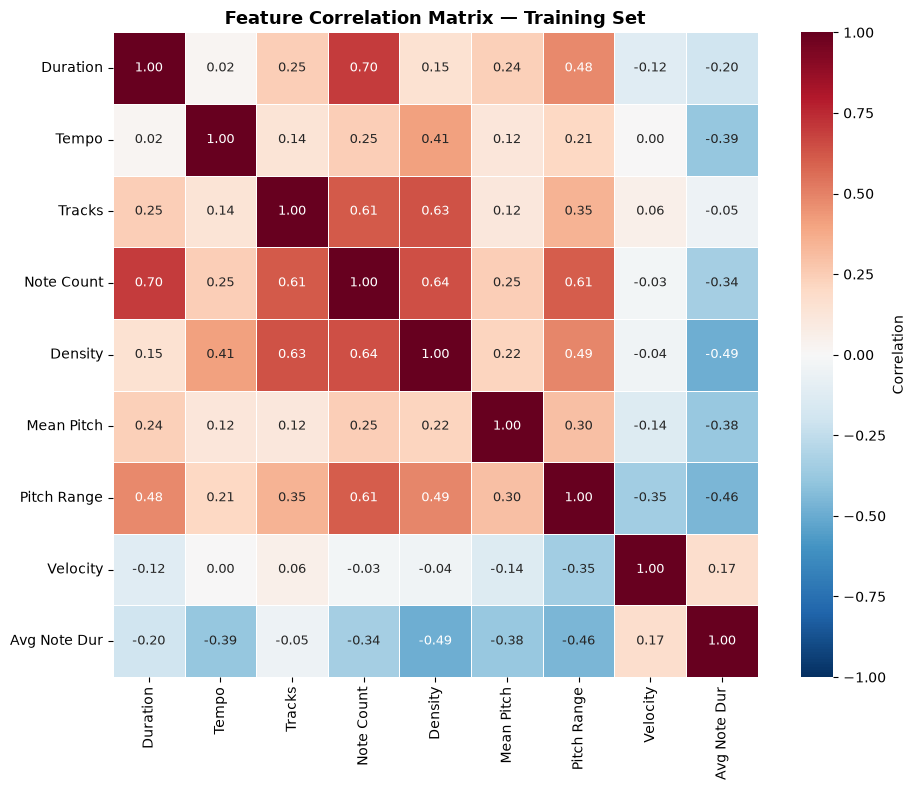

In [21]:
features = [
    "duration_s",
    "mean_tempo_bpm",
    "n_tracks",
    "n_notes",
    "note_density",
    "mean_pitch",
    "pitch_range",
    "mean_velocity",
    "mean_note_duration_s"
]

labels = [
    "Duration",
    "Tempo",
    "Tracks",
    "Note Count",
    "Density",
    "Mean Pitch",
    "Pitch Range",
    "Velocity",
    "Avg Note Dur"
]

corr = train_metadata_df[features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.4,
    annot_kws={"size": 9},
    cbar_kws={"label": "Correlation"}
)

plt.title(
    "Feature Correlation Matrix — Training Set",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 3.14 Class Separability Using PCA

Principal Component Analysis (PCA) is used to reduce the extracted musical features to two dimensions. The purpose of this visualization is to examine whether the composers form separate clusters based on the engineered statistical features. Substantial overlap would indicate that these summary features alone may not be sufficient and that sequence-based LSTM and CNN models are needed to learn more detailed musical patterns.

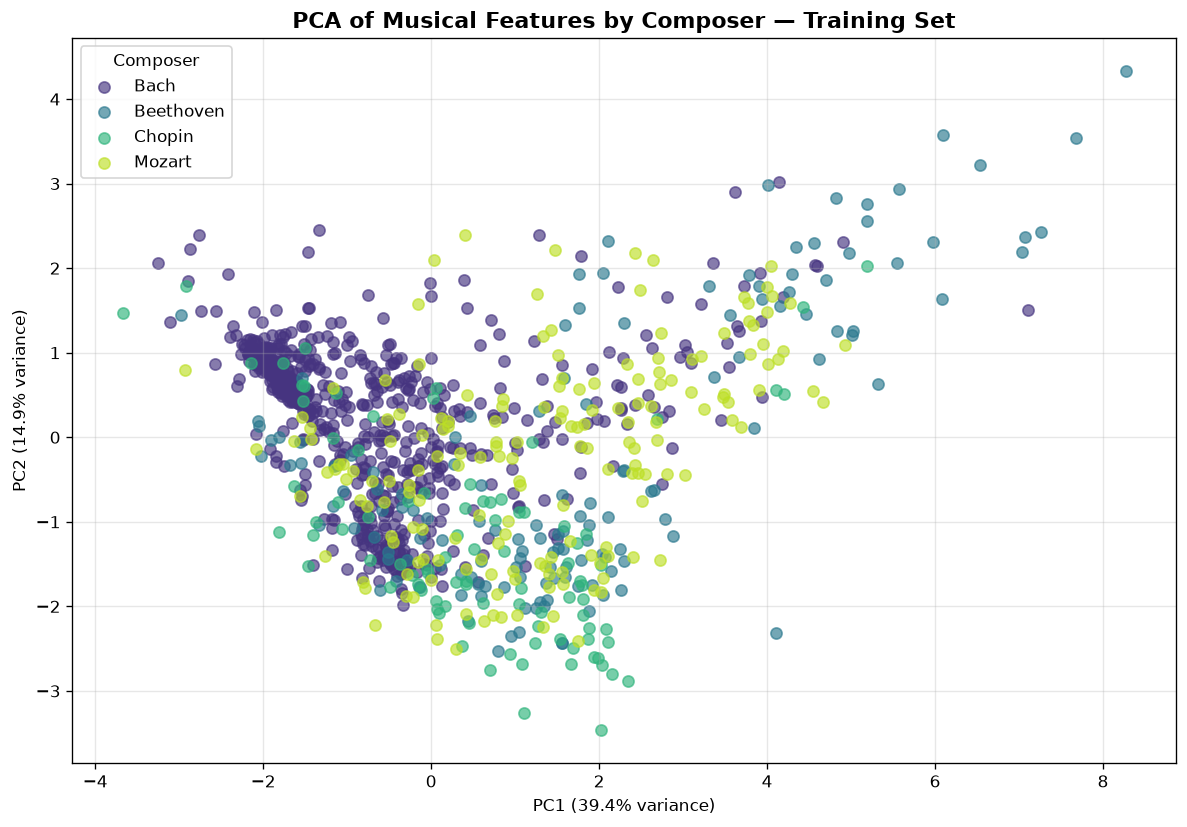

Explained variance ratio: [0.394 0.149]


In [22]:
pca_features = [
    "duration_s",
    "mean_tempo_bpm",
    "n_tracks",
    "n_notes",
    "note_density",
    "mean_pitch",
    "pitch_range",
    "mean_velocity",
    "mean_note_duration_s"
]


X_pca = train_metadata_df[pca_features].copy()
X_pca = X_pca.fillna(X_pca.median())
y_pca = train_metadata_df["composer"]
pca_scaler = StandardScaler()
X_pca_scaled = pca_scaler.fit_transform(X_pca)

# Reduce the data to two principal components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(
    X_pca_scaled
)

plt.figure(figsize=(10, 7), dpi=120)

pca_colors = plt.cm.viridis(
    np.linspace(0.15, 0.9, len(composer_names))
)

for index, composer in enumerate(composer_names):
    composer_mask = y_pca == composer

    plt.scatter(
        principal_components[composer_mask, 0],
        principal_components[composer_mask, 1],
        label=composer,
        color=pca_colors[index],
        alpha=0.65,
        s=45
    )

plt.xlabel(f"PC1 "f"({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")

plt.ylabel(f"PC2 "f"({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")

plt.title(
    "PCA of Musical Features by Composer — Training Set",
    fontsize=13,
    fontweight="bold"
)

plt.legend(title="Composer")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_.round(3)
)

### 3.15 Note-Duration Distribution by Composer

Note duration represents how long each musical note is held. Differences in note duration can reflect rhythmic style, articulation, and musical period. In this analysis, individual note durations from all training MIDI files are combined for each composer. A logarithmic horizontal scale is used because note durations vary substantially and shorter notes occur much more frequently than longer notes.

d:\AAI_511_Final_Project\music-composer-classification-pytorch\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
d:\AAI_511_Final_Project\music-composer-classification-pytorch\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
d:\AAI_511_Final_Project\music-composer-classification-pytorch\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
d:\AAI_511_Final_Project\music-composer-classification-pyt

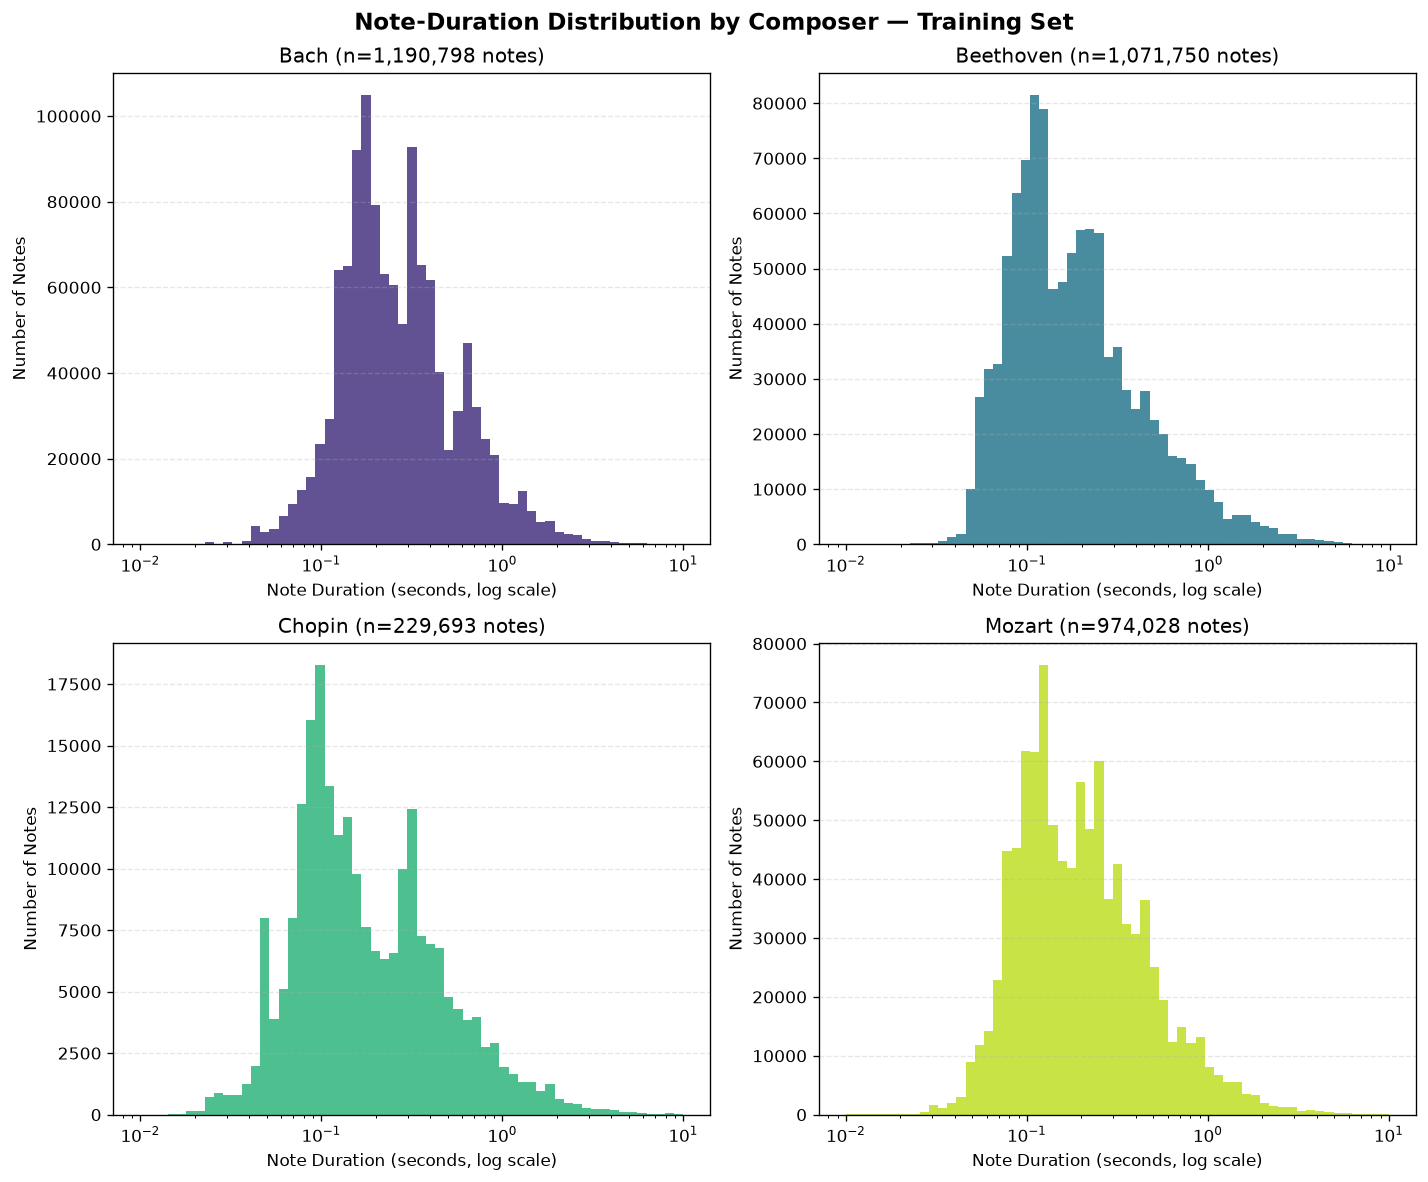

In [23]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10),
    dpi=120
)

axes = axes.flatten()

duration_colors = plt.cm.viridis(
    np.linspace(0.15, 0.9, len(composer_names))
)

for index, composer in enumerate(composer_names):

    composer_files = train_metadata_df[
        train_metadata_df["composer"] == composer
    ]

    all_note_durations = []

    for _, row in composer_files.iterrows():
        file_path = (
            RAW_DATA_DIR / row["relative_path"]
        )

        try:
            midi_data = pretty_midi.PrettyMIDI(
                str(file_path)
            )

            note_durations = [
                note.end - note.start
                for instrument in midi_data.instruments
                if not instrument.is_drum
                for note in instrument.notes
            ]

            all_note_durations.extend(note_durations)

        except Exception:
            continue

    durations = np.array(all_note_durations)

    # Removing invalid values and limiting extreme durations
    durations = durations[
        (durations > 0) & (durations <= 10)
    ]

    log_bins = np.logspace(
        np.log10(max(durations.min(), 0.01)),
        np.log10(durations.max()),
        60
    )

    ax = axes[index]

    ax.hist(
        durations,
        bins=log_bins,
        color=duration_colors[index],
        alpha=0.85
    )

    ax.set_xscale("log")

    ax.set_title(
        f"{composer} (n={len(durations):,} notes)"
    )

    ax.set_xlabel("Note Duration (seconds, log scale)")
    ax.set_ylabel("Number of Notes")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.suptitle(
    "Note-Duration Distribution by Composer — Training Set",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 3.16 EDA Summary

The exploratory data analysis examined the structure, quality, class distribution, and musical characteristics of the MIDI dataset before preprocessing and model development.

#### Dataset Quality and Distribution

The original dataset contained 1,630 MIDI files from Bach, Beethoven, Chopin, and Mozart. The integrity checks found no empty files, two corrupted files, and 20 exact duplicate files. After excluding these files, 1,608 clean and unique MIDI files remained. The cleaned files were divided into training, validation, and test sets using a reproducible stratified 70/15/15 split. The training set contains 1,125 files, the validation set contains 241 files, and the test set contains 242 files. The dataset is imbalanced. Bach has 709 training files, while Chopin has only 92. This imbalance will need to be considered during model training through class-weighted loss and training-set augmentation.

#### Musical Feature Findings

The training-set analysis showed several differences among the composers:

- Bach’s compositions generally had shorter durations, fewer notes per file, lower note density, and a narrower pitch range.
- Beethoven had the longest average duration and the largest average number of notes per file.
- Chopin had the widest average pitch range but the smallest number of available training files.
- Mozart had the highest average pitch among the four composers.
- Tempo, note density, pitch range, velocity, and note duration showed differences among composers, but no single feature completely separated the four classes.
- The piano-roll, pitch-distribution, and note-duration visualizations showed that each composer has recognizable musical patterns, although substantial overlap remains.

The first two PCA components explained approximately 54.3% of the variation in the engineered statistical features. The PCA visualization showed overlap among the composer classes, indicating that summary statistics alone are unlikely to provide complete separation.

#### Modeling Implications

The EDA supports using sequence-based deep learning models. The LSTM can learn temporal relationships among notes, while the CNN can identify local patterns in the fixed-length musical-feature sequences.

The following decisions will be used during modeling:

- Preserve the training, validation, and test assignments created before preprocessing.
- Calculate normalization values using only the training set.
- Apply data augmentation only to training samples.
- Use class weights to reduce the effect of class imbalance.
- Report accuracy, precision, recall, F1-score, and confusion matrices.
- Keep the test set separate until final model evaluation.

Overall, the cleaned MIDI dataset contains useful composer-specific patterns and provides a suitable foundation for training and comparing LSTM and CNN models.

---

## 4. MIDI Preprocessing

In this section, the cleaned MIDI files are converted into standardized numerical sequences suitable for deep learning.

The clean file manifest created in Section 3 is used as the starting point. This manifest already excludes empty, corrupted, and duplicate files and contains the fixed training, validation, and test assignment for every remaining MIDI file. These assignments are preserved throughout preprocessing.

For each MIDI file, notes from non-drum instrument tracks are collected and sorted by their starting time and pitch. Pitch, velocity, note duration, and note start time are extracted while maintaining the original musical order.

MIDI pitch values are encoded as integer tokens, with token `0` reserved for padding. Because the files contain different numbers of notes, all sequences are padded or truncated to a fixed length of 4,096 notes. This length is selected using only the training-set sequence distribution.

Composer names are also converted into numerical class labels for supervised learning.

The preprocessing process is organized into the following steps:

- **4.1** Load the Clean MIDI File Manifest
- **4.2** Extract Note Sequences
- **4.3** Encode Musical Notes
- **4.4** Create Fixed-Length Sequences
- **4.5** Encode Composer Labels
- **4.6** Prepare the Final Dataset
- **4.7** Preprocessing Summary

The resulting dataset preserves the original split assignment for every sample and provides the aligned sequences, labels, and file information required for feature extraction and model development.

### 4.1 Load the Clean MIDI File Manifest

The cleaned MIDI-file manifest created during EDA is used as the starting point for preprocessing. It contains the composer, file path, relative path, and assigned dataset split for every clean and unique MIDI file.

Using this manifest prevents the notebook from searching and filtering the files again and ensures that each file keeps the same training, validation, or test assignment throughout preprocessing and modeling.

In [24]:
valid_midi_df = file_manifest_df.copy()

print("Clean MIDI File Summary")
print("-" * 50)

valid_file_summary = pd.crosstab(
    valid_midi_df["composer"],
    valid_midi_df["split"]
)

valid_file_summary = valid_file_summary.reindex(
    index=composer_names,
    columns=["train", "validation", "test"],
    fill_value=0
)

valid_file_summary["total"] = (
    valid_file_summary.sum(axis=1)
)

display(valid_file_summary)

print(f"Total clean MIDI files: {len(valid_midi_df)}")

assert len(valid_midi_df) == 1608
assert valid_midi_df["split"].notna().all()

display(
    valid_midi_df[
        [
            "composer",
            "split",
            "relative_path"
        ]
    ].sample(5, random_state=SEED)
)

Clean MIDI File Summary
--------------------------------------------------


split,train,validation,test,total
composer,,,,
Bach,709,152,153,1014
Beethoven,146,31,31,208
Chopin,92,20,20,132
Mozart,178,38,38,254


Total clean MIDI files: 1608


,composer,split,relative_path
687,Bach,train,Bach\Bwv001- 400 Chorales\007507b_.mid
968,Bach,train,Bach\Bwv1080 The Art Of Fugue\The Art of the F...
165,Chopin,train,Chopin\Prelude n17 op28 ''Scene On the Place o...
595,Bach,train,Bach\Bwv0733 Fuga Sopra Magnificat.mid
1127,Bach,validation,Bach\Bwv0811 English Suite n6 7mov.mid


### 4.2 Extract Note Sequences

- Parse each valid MIDI file
- Collect notes from all instrument tracks
- Order notes by their starting time
- Store the sequence with its composer label
- Remove files that contain no usable notes

In this step, we extract a sequence of MIDI pitch values from each valid file. Notes from all non-drum instrument tracks are combined and sorted by their starting time so that the original musical order is preserved. Each extracted sequence is stored together with the corresponding composer label and file information. Files that cannot be parsed or do not contain usable notes are excluded from the remaining preprocessing steps. The resulting variable-length note sequences will later be converted into numerical model inputs and standardized to a fixed length.

In [25]:
note_sequence_records = []
sequence_extraction_errors = []
files_without_notes = []

for row in valid_midi_df.itertuples(index=False):
    composer = row.composer
    split = row.split
    file_path = row.file_path
    relative_path = row.relative_path

    try:
        midi_data = pretty_midi.PrettyMIDI(str(file_path))

        # Collecting notes from all non drum instrument tracks
        note_events = [
            note
            for instrument in midi_data.instruments
            if not instrument.is_drum
            for note in instrument.notes
        ]

        # Sort notes by start time, then pitch for simultaneous notes
        note_events.sort(key=lambda note: (note.start, note.pitch))

        # Exclude MIDI files without usable melodic notes
        if not note_events:
            files_without_notes.append(relative_path)
            continue

        # Extract note level sequences
        pitch_sequence = [note.pitch for note in note_events]
        velocity_sequence = [note.velocity for note in note_events]
        duration_sequence = [
            note.end - note.start
            for note in note_events
        ]
        start_time_sequence = [note.start for note in note_events]

        note_sequence_records.append(
            {
                "composer": composer,
                "split": split,
                "file_path": file_path,
                "relative_path": relative_path,
                "pitch_sequence": pitch_sequence,
                "velocity_sequence": velocity_sequence,
                "duration_sequence": duration_sequence,
                "start_time_sequence": start_time_sequence,
                "sequence_length": len(pitch_sequence),
            }
        )

    except Exception as error:
        sequence_extraction_errors.append(
            {
                "relative_path": relative_path,
                "error": str(error),
            }
        )

note_sequences_df = pd.DataFrame(note_sequence_records)

print("Note Sequence Extraction Summary")
print("\n")
print(f"Valid files received : {len(valid_midi_df)}")
print(f"Sequences successfully made : {len(note_sequences_df)}")
print(f"Files without usable notes : {len(files_without_notes)}")
print(f"Additional parsing errors : {len(sequence_extraction_errors)}")
print("\n")

sequence_counts = pd.crosstab(
    note_sequences_df["composer"],
    note_sequences_df["split"]
)

sequence_counts = sequence_counts.reindex(
    index=composer_names,
    columns=["train", "validation", "test"],
    fill_value=0
)

display(sequence_counts)

display(
    note_sequences_df[
        [
            "composer",
            "split",
            "relative_path",
            "sequence_length",
            "pitch_sequence",
        ]
    ].head()
)

d:\AAI_511_Final_Project\music-composer-classification-pytorch\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Note Sequence Extraction Summary


Valid files received : 1608
Sequences successfully made : 1608
Files without usable notes : 0
Additional parsing errors : 0




split,train,validation,test
composer,,,
Bach,709,152,153
Beethoven,146,31,31
Chopin,92,20,20
Mozart,178,38,38


,composer,split,relative_path,sequence_length,pitch_sequence
0,Bach,train,Bach\Bwv232 Mass\06. Chor Gratias Animus Tibi ...,3035,"[50, 50, 50, 50, 52, 52, 52, 52, 54, 54, 54, 5..."
1,Bach,train,Bach\Bwv001- 400 Chorales\009709b_.mid,388,"[46, 62, 65, 65, 70, 70, 74, 63, 72, 58, 62, 6..."
2,Beethoven,train,Beethoven\Hess074 Bagatella.mid,534,"[70, 46, 53, 56, 58, 46, 53, 56, 58, 46, 53, 5..."
3,Bach,train,Bach\Bwv001- 400 Chorales\041600b_.mid,216,"[50, 62, 65, 69, 49, 57, 64, 69, 50, 57, 62, 6..."
4,Mozart,train,Mozart\Piano Concertos\Piano Concerto n26 K537...,13208,"[38, 50, 50, 62, 38, 50, 50, 64, 62, 61, 38, 5..."


### 4.3 Encode Musical Notes

- Convert MIDI pitch values into integer tokens
- Reserve a separate value for padding
- Keep the original order of the notes

The extracted pitch sequences already contain numerical MIDI pitch values from 0 to 127. However, we need a separate value for padding when the sequences are standardized in the next step. To avoid confusing a real MIDI pitch with a padding value, we reserve `0` for padding and shift every pitch value up by one. This means MIDI pitches from 0 to 127 are encoded as values from 1 to 128. The order of the notes remains unchanged, so the encoded sequences still represent the original musical progression of each MIDI file.

In [26]:
PADDING_TOKEN = 0

# Shift MIDI pitches from 0–127 to encoded tokens 1–128
note_sequences_df["encoded_pitch_sequence"] = (
    note_sequences_df["pitch_sequence"]
    .apply(lambda sequence: [pitch + 1 for pitch in sequence])
)

MIN_ENCODED_PITCH = 1
MAX_ENCODED_PITCH = 128
VOCAB_SIZE = 129  # Padding token + 128 possible MIDI pitches

print("Musical Note Encoding Summary")
print("\n")
print(f"Padding token : {PADDING_TOKEN}")
print(f"Encoded pitch range : {MIN_ENCODED_PITCH} to {MAX_ENCODED_PITCH}")
print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"Sequences encoded : {len(note_sequences_df)}")
print("\n")


example_index = 0

print("Original pitch sequence:")
print(note_sequences_df.loc[example_index, "pitch_sequence"][:20])

print("\nEncoded pitch sequence:")
print(note_sequences_df.loc[example_index, "encoded_pitch_sequence"][:20])

Musical Note Encoding Summary


Padding token : 0
Encoded pitch range : 1 to 128
Vocabulary size : 129
Sequences encoded : 1608


Original pitch sequence:
[50, 50, 50, 50, 52, 52, 52, 52, 54, 54, 54, 54, 57, 57, 55, 55, 55, 55, 59, 59]

Encoded pitch sequence:
[51, 51, 51, 51, 53, 53, 53, 53, 55, 55, 55, 55, 58, 58, 56, 56, 56, 56, 60, 60]


### 4.4 Create Fixed-Length Sequences

The extracted note sequences have different lengths because each MIDI file contains a different number of notes. However, the LSTM and CNN models need inputs with the same length within each batch. In this step, we convert every encoded pitch sequence to a fixed length. Shorter sequences are padded with the reserved padding token `0`, while longer sequences are truncated. To choose a reasonable sequence length, we first review the sequence-length distribution and select a value that keeps most of the musical information without making the model unnecessarily large or slow.

Sequence Length Summary
----------------------------------------
count     1125.00
mean      3081.67
std       4554.68
min         83.00
25%        378.00
50%       1179.00
75%       3791.00
max      33835.00
Name: sequence_length, dtype: float64

Training_Sequence Length Percentiles
----------------------------------------
0.50     1179.0
0.75     3791.0
0.90     8524.0
0.95    12538.0
0.99    20497.0
Name: sequence_length, dtype: float64


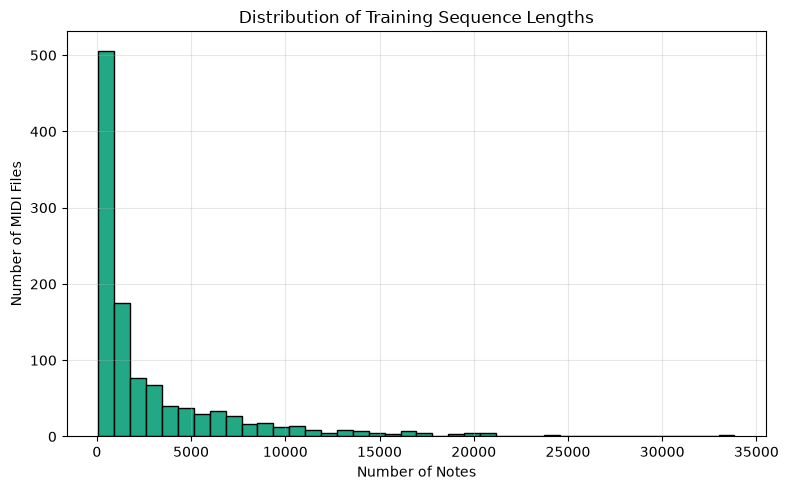

In [27]:
training_sequence_lengths = note_sequences_df.loc[
    note_sequences_df["split"] == "train",
    "sequence_length"
]

print("Sequence Length Summary")
print("-" * 40)
print(training_sequence_lengths.describe().round(2))

print("\nTraining_Sequence Length Percentiles")
print("-" * 40)
print(training_sequence_lengths.quantile([0.50, 0.75, 0.90, 0.95, 0.99]).round())

plt.figure(figsize=(8, 5))

plt.hist(training_sequence_lengths,bins=40,color=plt.cm.viridis(0.6),edgecolor="black")

plt.title("Distribution of Training Sequence Lengths")
plt.xlabel("Number of Notes")
plt.ylabel("Number of MIDI Files")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The maximum sequence length is selected using only the training-set distribution. The median training sequence contains 1,179 notes, and the 75th percentile contains 3791 notes. Therefore, a fixed length of 4096 notes is used as a balance between retaining musical information and controlling memory usage and training time. Sequences longer than 4,096 notes are truncated, while shorter sequences are padded with zeros. The same fixed length is then applied to the validation and test sets.

In [28]:
# Pad or truncate every sequence
MAX_SEQUENCE_LENGTH = 4096
fully_preserved_percentage = (
    (
        training_sequence_lengths
        <= MAX_SEQUENCE_LENGTH
    ).mean()
    * 100
)
PADDING_VALUE = 0

fixed_length_sequences = []

for sequence in note_sequences_df["encoded_pitch_sequence"]:

    if len(sequence) >= MAX_SEQUENCE_LENGTH:
        fixed_sequence = sequence[:MAX_SEQUENCE_LENGTH]

    else:
        fixed_sequence = sequence + [PADDING_VALUE] * (
            MAX_SEQUENCE_LENGTH - len(sequence)
        )

    fixed_length_sequences.append(fixed_sequence)

note_sequences_df["fixed_sequence"] = fixed_length_sequences

print("Fixed-Length Sequence Summary")
print("\n")
print(f"Selected maximum sequence length : {MAX_SEQUENCE_LENGTH}")
print(f"Training files fully preserved : "f"{fully_preserved_percentage:.1f}%")
print(f"Padding value : {PADDING_VALUE}")
print(f"Total sequences : {len(note_sequences_df)}")
print()

print("Example")
print("Original length :", note_sequences_df.iloc[0]["sequence_length"])
print("Fixed length :", len(note_sequences_df.iloc[0]["fixed_sequence"]))
print()
print("All sequences now have a uniform length and are ready for model training.")

display(
    note_sequences_df[
        ["composer", "sequence_length", "fixed_sequence"]
    ].head()
)

Fixed-Length Sequence Summary


Selected maximum sequence length : 4096
Training files fully preserved : 76.0%
Padding value : 0
Total sequences : 1608

Example
Original length : 3035
Fixed length : 4096

All sequences now have a uniform length and are ready for model training.


,composer,sequence_length,fixed_sequence
0,Bach,3035,"[51, 51, 51, 51, 53, 53, 53, 53, 55, 55, 55, 5..."
1,Bach,388,"[47, 63, 66, 66, 71, 71, 75, 64, 73, 59, 63, 6..."
2,Beethoven,534,"[71, 47, 54, 57, 59, 47, 54, 57, 59, 47, 54, 5..."
3,Bach,216,"[51, 63, 66, 70, 50, 58, 65, 70, 51, 58, 63, 6..."
4,Mozart,13208,"[39, 51, 51, 63, 39, 51, 51, 65, 63, 62, 39, 5..."


### 4.5 Encode Composer Labels

The composer names need to be converted into numerical class labels before they can be used for supervised learning. In this step, each composer is assigned a fixed integer value:

- Bach      -> 0
- Beethoven -> 1
- Chopin    -> 2
- Mozart    -> 3

These labels will be used as the target values during model training. Keeping the mapping fixed also makes it easier to interpret predictions and evaluation results later.

In [29]:
# Define the label mapping
composer_to_label = {
    "Bach": 0,
    "Beethoven": 1,
    "Chopin": 2,
    "Mozart": 3
}

note_sequences_df["label"] = (
    note_sequences_df["composer"]
    .map(composer_to_label)
)

# Create the reverse mapping
label_to_composer = {
    value: key
    for key, value in composer_to_label.items()
}

print("Composer Label Encoding")
print("-" * 40)

for composer, label in composer_to_label.items():
    print(f"{composer:<10} -> {label}")

print("-" * 40)
print(f"Total labeled samples : {len(note_sequences_df)}")

display(
    note_sequences_df[
        ["composer", "label"]
    ].head(10)
)

Composer Label Encoding
----------------------------------------
Bach       -> 0
Beethoven  -> 1
Chopin     -> 2
Mozart     -> 3
----------------------------------------
Total labeled samples : 1608


,composer,label
0,Bach,0
1,Bach,0
2,Beethoven,1
3,Bach,0
4,Mozart,3
5,Bach,0
6,Beethoven,1
7,Bach,0
8,Bach,0
9,Bach,0


### 4.6 Prepare the Final Dataset

At this point, every MIDI file has been converted into a fixed-length numerical sequence and assigned a numerical composer label. In this step, we combine the processed sequences and labels into the final dataset that will be used for model training. The feature matrix contains the encoded note sequences, while the target vector contains the corresponding composer labels. The original training, validation, and test assignments are preserved so that the same MIDI file cannot appear in more than one dataset split.

In [30]:
X = np.array(
    note_sequences_df["fixed_sequence"].tolist(),
    dtype=np.int64
)

y = note_sequences_df["label"].to_numpy(dtype=np.int64)

sample_splits = note_sequences_df["split"].to_numpy()

sample_metadata_df = note_sequences_df[
    [
        "composer",
        "label",
        "split",
        "relative_path",
        "sequence_length"
    ]
].copy()

print("Final Dataset Summary")
print("-" * 45)
print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape : {y.shape}")
print(f"Feature data type : {X.dtype}")
print(f"Target data type : {y.dtype}")
print(f"Minimum token value : {X.min()}")
print(f"Maximum token value : {X.max()}")
print(f"Number of classes : {len(np.unique(y))}")
print("\nSamples by split:")
print(sample_metadata_df["split"].value_counts().reindex(["train", "validation", "test"]))
print("-" * 45)

assert X.shape == (
    len(note_sequences_df),
    MAX_SEQUENCE_LENGTH
), "The feature matrix has an unexpected shape."

assert len(X) == len(y), (
    "The number of feature sequences does not match "
    "the number of labels."
)

assert len(sample_splits) == len(X)
assert sample_metadata_df["split"].notna().all()

assert X.min() >= PADDING_TOKEN
assert X.max() < VOCAB_SIZE

print("Dataset checks passed successfully.")

display(sample_metadata_df.head())

Final Dataset Summary
---------------------------------------------
Feature matrix shape : (1608, 4096)
Target vector shape : (1608,)
Feature data type : int64
Target data type : int64
Minimum token value : 0
Maximum token value : 102
Number of classes : 4

Samples by split:
split
train         1125
validation     241
test           242
Name: count, dtype: int64
---------------------------------------------
Dataset checks passed successfully.


,composer,label,split,relative_path,sequence_length
0,Bach,0,train,Bach\Bwv232 Mass\06. Chor Gratias Animus Tibi ...,3035
1,Bach,0,train,Bach\Bwv001- 400 Chorales\009709b_.mid,388
2,Beethoven,1,train,Beethoven\Hess074 Bagatella.mid,534
3,Bach,0,train,Bach\Bwv001- 400 Chorales\041600b_.mid,216
4,Mozart,3,train,Mozart\Piano Concertos\Piano Concerto n26 K537...,13208


### 4.7 Preprocessing Summary

The preprocessing pipeline converted the cleaned MIDI files into fixed-length numerical sequences suitable for the LSTM and CNN models.

The main preprocessing steps included:

- Using the clean dataset manifest created during EDA
- Preserving each file’s training, validation, or test assignment
- Extracting notes from non-drum instrument tracks
- Ordering notes by start time and pitch
- Encoding MIDI pitches as integer tokens
- Reserving token `0` for sequence padding
- Selecting the maximum sequence length using only training data
- Padding or truncating every sequence to 4,096 notes
- Encoding the four composer labels as integers

The final preprocessing dataset contains 1,608 MIDI files represented as sequences of 4,096 note tokens. Approximately 76% of the training files are fully preserved without truncation. The dataset contains 1,125 training samples, 241 validation samples, and 242 test samples. These assignments will remain unchanged during feature extraction, normalization, model training, and evaluation.

---

## 5. Feature Extraction

In this section, we prepare the musical features that will be used as input to the deep learning models. During preprocessing, we extracted pitch, velocity, note duration, and note start time from each valid MIDI file. Here, we organize those values into numerical feature representations while keeping the original order of the notes.

The extracted features include:

- Encoded MIDI pitch
- Note velocity
- Note duration
- Time interval between consecutive notes
- Sequence length
- Composer label

Pitch represents how high or low a note is, velocity represents how strongly the note is played, and note duration represents how long the note is held. The time interval between notes provides information about rhythm and timing. The LSTM model will use sequential features to learn patterns across time. The CNN model will use the same organized sequences to identify local musical patterns. Padding and truncation will be applied consistently so that all feature arrays have the same length.

The feature extraction process is organized into the following steps:

- **5.1** Calculate Time Intervals Between Notes
- **5.2** Prepare Continuous Features for Normalization
- **5.3** Create Multi-Feature Sequences
- **5.4** Verify Feature Shapes and Values
- **5.5** Feature Extraction Summary

The final output of this section is an organized numerical feature representation for each MIDI file, together with its composer label and original dataset split. In the next section, the existing assignments are used to create the training, validation, and test arrays before normalization is calculated from training data only.

### 5.1 Calculate Time Intervals Between Notes

The start times extracted from each MIDI file show when every note begins. In this step, we calculate the time interval between each note and the note that comes before it. The first note in each sequence is assigned an interval of `0` because there is no earlier note to compare it with. Notes that begin at the same time also have an interval of `0`, which commonly happens when several notes are played together as a chord. These intervals provide useful timing and rhythmic information that pitch values alone do not capture. They will be included with pitch, velocity, and note duration when the final feature sequences are created.

In [31]:
# Calculate the time between consecutive note start times.
def calculate_time_intervals(start_times):

    start_times = np.asarray(start_times, dtype=np.float32)

    if len(start_times) == 0:
        return []

    time_intervals = np.diff(
        start_times,
        prepend=start_times[0]
    )

    time_intervals = np.maximum(time_intervals, 0.0)

    return time_intervals.tolist()

note_sequences_df["time_interval_sequence"] = (
    note_sequences_df["start_time_sequence"]
    .apply(calculate_time_intervals)
)

interval_lengths_match = all(
    len(intervals) == len(pitches)
    for intervals, pitches in zip(
        note_sequences_df["time_interval_sequence"],
        note_sequences_df["pitch_sequence"]
    )
)

print("Time Interval Extraction Summary\n")
print(f"Sequences processed : {len(note_sequences_df)}")
print(f"Sequence lengths match : {interval_lengths_match}\n")

example_index = 0

print("Example note start times:")
print(
    note_sequences_df.loc[
        example_index,
        "start_time_sequence"
    ][:20]
)

print("\nCalculated time intervals:")
print(
    note_sequences_df.loc[
        example_index,
        "time_interval_sequence"
    ][:20]
)

Time Interval Extraction Summary

Sequences processed : 1608
Sequence lengths match : True

Example note start times:
[np.float64(5.857142), np.float64(5.857142), np.float64(5.857142), np.float64(5.857142), np.float64(6.714284), np.float64(6.714284), np.float64(6.714284), np.float64(6.714284), np.float64(7.571426000000001), np.float64(7.571426000000001), np.float64(7.571426000000001), np.float64(7.571426000000001), np.float64(7.571426000000001), np.float64(7.571426000000001), np.float64(8.428568), np.float64(8.428568), np.float64(8.428568), np.float64(8.428568), np.float64(8.428568), np.float64(8.428568)]

Calculated time intervals:
[0.0, 0.0, 0.0, 0.0, 0.8571419715881348, 0.0, 0.0, 0.0, 0.8571419715881348, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8571419715881348, 0.0, 0.0, 0.0, 0.0, 0.0]


### 5.2 Prepare Continuous Features for Normalization

The continuous features have different numerical ranges. MIDI velocity values range from 0 to 127, while note durations and time intervals can vary considerably across musical pieces.

To prevent information from the test set from influencing model preparation, normalization is not performed at this stage. The existing split assignments will be used in Section 6, where normalization parameters are calculated from training data only and applied unchanged to the validation and test data.

At this stage, the original velocity, note duration, and time interval sequences are preserved. The encoded pitch values also remain unchanged because they will be treated as integer tokens by the embedding layer.

In [32]:
def prepare_continuous_sequence(sequence, feature_name):
    """
    Convert a continuous feature sequence to float32 and verify
    that it contains valid, finite, non-negative values.
    """
    values = np.asarray(sequence, dtype=np.float32)

    if values.ndim != 1:
        raise ValueError(f"{feature_name} must be a one-dimensional sequence.")

    if not np.all(np.isfinite(values)):
        raise ValueError(f"{feature_name} contains NaN or infinite values.")

    if np.any(values < 0):
        raise ValueError(f"{feature_name} contains negative values.")

    return values.tolist()

note_sequences_df["prepared_velocity_sequence"] = (
    note_sequences_df["velocity_sequence"]
    .apply(lambda sequence: prepare_continuous_sequence(
        sequence,
        "Velocity sequence"
    ))
)

note_sequences_df["prepared_duration_sequence"] = (
    note_sequences_df["duration_sequence"]
    .apply(lambda sequence: prepare_continuous_sequence(
        sequence,
        "Duration sequence"
    ))
)

note_sequences_df["prepared_interval_sequence"] = (
    note_sequences_df["time_interval_sequence"]
    .apply(lambda sequence: prepare_continuous_sequence(
        sequence,
        "Time interval sequence"
    ))
)

required_sequence_columns = [
    "encoded_pitch_sequence",
    "prepared_velocity_sequence",
    "prepared_duration_sequence",
    "prepared_interval_sequence"
]


# Check whether all note-level feature sequences for one MIDI file
# have the same number of elements.
def feature_lengths_match(row):

    lengths = [
        len(row[column])
        for column in required_sequence_columns
    ]

    return len(set(lengths)) == 1


note_sequences_df["feature_lengths_match"] = (
    note_sequences_df.apply(feature_lengths_match, axis=1)
)

training_note_sequences_df = note_sequences_df[
    note_sequences_df["split"] == "train"
].copy()

all_velocities = np.concatenate([
    np.asarray(sequence, dtype=np.float32)
    for sequence in training_note_sequences_df["prepared_velocity_sequence"]
    if len(sequence) > 0
])

all_durations = np.concatenate([
    np.asarray(sequence, dtype=np.float32)
    for sequence in training_note_sequences_df["prepared_duration_sequence"]
    if len(sequence) > 0
])

all_intervals = np.concatenate([
    np.asarray(sequence, dtype=np.float32)
    for sequence in training_note_sequences_df["prepared_interval_sequence"]
    if len(sequence) > 0
])



print("Continuous Feature Preparation Summary")
print("---------------------")
print(f"MIDI sequences prepared : {len(note_sequences_df)}")
print(f"All feature lengths match : "f"{note_sequences_df['feature_lengths_match'].all()}")
print("-----------------------")

print(f"Training Velocity range : "f"{all_velocities.min():.4f} to {all_velocities.max():.4f}")
print(f"Training Duration range : "f"{all_durations.min():.4f} to {all_durations.max():.4f}")
print(f"Training Time interval range : "f"{all_intervals.min():.4f} to {all_intervals.max():.4f}")

print("-----------------------")
print("Normalization applied : False")
print("Continuous features preserved for train-only normalization.")

Continuous Feature Preparation Summary
---------------------
MIDI sequences prepared : 1608
All feature lengths match : True
-----------------------
Training Velocity range : 1.0000 to 127.0000
Training Duration range : 0.0004 to 98.6393
Training Time interval range : 0.0000 to 21.3862
-----------------------
Normalization applied : False
Continuous features preserved for train-only normalization.


### 5.3 Create Multi-Feature Sequences

In this step, the encoded pitch, velocity, note duration, and time interval values are combined into one feature sequence for each MIDI file. Each note is represented by four aligned values:

1. Encoded pitch
2. Velocity
3. Note duration
4. Time interval from the previous note

The original order of the notes is preserved so the models can learn musical patterns across time. Because the continuous features have not yet been normalized, the resulting sequences contain the original prepared values. The existing training, validation, and test assignments are preserved. Final normalization will use parameters calculated from the training data only and apply them unchanged to the validation and test data. All sequences are padded or truncated to the same length of 4,096 notes. Padding positions are filled with zeros. The final output for each MIDI file has the shape: `(4096, 4)`
where 4 represents the four note-level features.

In [33]:
# Using the same sequence length selected during preprocessing
FEATURE_SEQUENCE_LENGTH = MAX_SEQUENCE_LENGTH
NUMBER_OF_FEATURES = 4

FEATURE_NAMES = [
    "Encoded Pitch",
    "Velocity",
    "Duration",
    "Time Interval"
]

# Pad a sequence with zeros or truncate it to the target length.
def pad_or_truncate(sequence, target_length, dtype=np.float32):

    values = np.asarray(sequence, dtype=dtype)
    if len(values) >= target_length:
        return values[:target_length]

    padded_values = np.zeros(target_length, dtype=dtype)
    padded_values[:len(values)] = values

    return padded_values


"""
Create one aligned feature matrix for a MIDI file.
Column order:
0 = encoded pitch
1 = velocity
2 = duration
3 = time interval
"""
def create_multi_feature_sequence(row, target_length=FEATURE_SEQUENCE_LENGTH):

    pitch = pad_or_truncate(
        row["encoded_pitch_sequence"],
        target_length,
        dtype=np.int64
    )

    velocity = pad_or_truncate(
        row["prepared_velocity_sequence"],
        target_length,
        dtype=np.float32
    )

    duration = pad_or_truncate(
        row["prepared_duration_sequence"],
        target_length,
        dtype=np.float32
    )

    interval = pad_or_truncate(
        row["prepared_interval_sequence"],
        target_length,
        dtype=np.float32
    )

    # Combining integer and continuous features creates a float32 matrix.
    # The pitch column will be converted back to int64 before embedding.
    feature_matrix = np.column_stack([
        pitch,
        velocity,
        duration,
        interval
    ]).astype(np.float32)

    return feature_matrix


# one fixed-size multi-feature sequence for each MIDI file
note_sequences_df["multi_feature_sequence"] = (
    note_sequences_df.apply(
        create_multi_feature_sequence,
        axis=1
    )
)


# complete feature array
X_features = np.stack(
    note_sequences_df["multi_feature_sequence"].to_numpy()
).astype(np.float32)

# Preserve composer labels as integers
y_features = note_sequences_df["label"].to_numpy(dtype=np.int64)
# Preserve the split assignment for every feature sequence
feature_splits = note_sequences_df[
    "split"
].to_numpy()


# Verify the results
expected_shape = (
    len(note_sequences_df),
    FEATURE_SEQUENCE_LENGTH,
    NUMBER_OF_FEATURES
)

all_shapes_correct = all(
    sequence.shape == (
        FEATURE_SEQUENCE_LENGTH,
        NUMBER_OF_FEATURES
    )
    for sequence in note_sequences_df["multi_feature_sequence"]
)

contains_nan = np.isnan(X_features).any()
contains_infinite = np.isinf(X_features).any()

print("Multi-Feature Sequence Summary")
print("----------------------------")
print(f"MIDI sequences created : {len(X_features)}")
print(f"Sequence length : {FEATURE_SEQUENCE_LENGTH}")
print(f"Features per note : {NUMBER_OF_FEATURES}")
print(f"Feature names : {FEATURE_NAMES}")
print(f"Complete feature array shape : {X_features.shape}")
print(f"Target array shape : {y_features.shape}")
print("\nFeature sequences by split:")
print(pd.Series(feature_splits).value_counts().reindex(["train", "validation", "test"]))
print(f"Expected shape obtained : {X_features.shape == expected_shape}")
print(f"All sequence shapes correct : {all_shapes_correct}")
print(f"Contains NaN values : {contains_nan}")
print(f"Contains infinite values : {contains_infinite}")
print("----------------------------")

# Verify that features, labels, and split assignments align
assert len(X_features) == len(y_features)
assert len(X_features) == len(feature_splits)

# Display the first 10 note-level feature rows from one MIDI file
example_index = 0

print("\nExample feature rows:")
print("Columns: [encoded pitch, velocity, duration, time interval]")
print(X_features[example_index, :10])

Multi-Feature Sequence Summary
----------------------------
MIDI sequences created : 1608
Sequence length : 4096
Features per note : 4
Feature names : ['Encoded Pitch', 'Velocity', 'Duration', 'Time Interval']
Complete feature array shape : (1608, 4096, 4)
Target array shape : (1608,)

Feature sequences by split:
train         1125
validation     241
test           242
Name: count, dtype: int64
Expected shape obtained : True
All sequence shapes correct : True
Contains NaN values : False
Contains infinite values : False
----------------------------

Example feature rows:
Columns: [encoded pitch, velocity, duration, time interval]
[[51.       40.        0.857142  0.      ]
 [51.       40.        0.857142  0.      ]
 [51.       40.        0.857142  0.      ]
 [51.       40.        0.857142  0.      ]
 [53.       40.        0.857142  0.857142]
 [53.       40.        0.857142  0.      ]
 [53.       40.        0.857142  0.      ]
 [53.       40.        0.857142  0.      ]
 [55.       40.    

### 5.4 Verify Feature Shapes and Values

Before saving and using the extracted features, several final checks are performed to confirm that the data is complete and correctly organized.

The verification process checks that:

- The feature array has the expected shape
- Every MIDI file has 4,096 time steps
- Each time step contains four features
- The number of feature sequences matches the number of composer labels
- Encoded pitch values are within the expected token range
- Velocity values remain within the MIDI range of 0 to 127
- Duration and time interval values are non-negative
- No missing or infinite values are present
- Padding rows contain zeros

These checks help identify formatting or data-quality problems before the existing split assignments are used to create the training, validation, and test arrays.

In [34]:
EXPECTED_SAMPLES = len(note_sequences_df)
EXPECTED_SEQUENCE_LENGTH = FEATURE_SEQUENCE_LENGTH
EXPECTED_FEATURE_COUNT = NUMBER_OF_FEATURES

pitch_values = X_features[:, :, 0]
velocity_values = X_features[:, :, 1]
duration_values = X_features[:, :, 2]
interval_values = X_features[:, :, 3]

non_padding_mask = pitch_values != 0
padding_mask = pitch_values == 0

feature_shape_correct = X_features.shape == (
    EXPECTED_SAMPLES,
    EXPECTED_SEQUENCE_LENGTH,
    EXPECTED_FEATURE_COUNT
)

label_shape_correct = y_features.shape == (EXPECTED_SAMPLES,)
sample_counts_match = len(X_features) == len(y_features)

split_shape_correct = (
    feature_splits.shape == (EXPECTED_SAMPLES,)
)

valid_split_values = set(
    np.unique(feature_splits)
) == {
    "train",
    "validation",
    "test"
}

# Missing and infinite value checks
contains_nan = np.isnan(X_features).any()
contains_infinite = np.isinf(X_features).any()

# Encoded pitch checks
pitch_values_are_integers = np.all(
    pitch_values == np.floor(pitch_values)
)

pitch_range_valid = (
    pitch_values.min() >= 0
    and pitch_values.max() <= 128
)

# Continuous feature checks on real notes only
velocity_range_valid = (
    velocity_values[non_padding_mask].min() >= 0
    and velocity_values[non_padding_mask].max() <= 127
)

duration_values_valid = np.all(
    duration_values[non_padding_mask] >= 0
)

interval_values_valid = np.all(
    interval_values[non_padding_mask] >= 0
)

padding_rows_are_zero = np.all(
    X_features[padding_mask] == 0
)

unique_labels = np.unique(y_features)

labels_are_integers = np.issubdtype(
    y_features.dtype,
    np.integer
)

label_range_valid = np.array_equal(
    unique_labels,
    np.arange(len(unique_labels))
)

validation_results = {
    "Feature shape correct": feature_shape_correct,
    "Label shape correct": label_shape_correct,
    "Sample counts match": sample_counts_match,
    "Contains NaN values": contains_nan,
    "Contains infinite values": contains_infinite,
    "Pitch values are integers": pitch_values_are_integers,
    "Pitch range valid": pitch_range_valid,
    "Velocity range valid": velocity_range_valid,
    "Duration values non-negative": duration_values_valid,
    "Interval values non-negative": interval_values_valid,
    "Padding rows contain zeros": padding_rows_are_zero,
    "Labels are integers": labels_are_integers,
    "Split shape correct": split_shape_correct,
    "Split values valid": valid_split_values,
    "Label range valid": label_range_valid
}

all_checks_passed = all([
    feature_shape_correct,
    label_shape_correct,
    sample_counts_match,
    not contains_nan,
    not contains_infinite,
    pitch_values_are_integers,
    pitch_range_valid,
    velocity_range_valid,
    duration_values_valid,
    interval_values_valid,
    padding_rows_are_zero,
    labels_are_integers,
    split_shape_correct,
    valid_split_values,
    label_range_valid
])

print("Feature Verification Summary")
print("-----------------------------" )
print(f"Feature array shape : {X_features.shape}")
print(f"Target array shape  : {y_features.shape}")
print(f"Feature data type  : {X_features.dtype}")
print(f"Target data type  : {y_features.dtype}")
print(f"Unique composer labels : {unique_labels.tolist()}")
print(f"Dataset split values  : " f"{np.unique(feature_splits).tolist()}")
print("------------------------------")

for check_name, result in validation_results.items():
    print(f"{check_name:<33}: {result}")

print("--------------------------")
print(f"All verification checks passed: {all_checks_passed}")

Feature Verification Summary
-----------------------------
Feature array shape : (1608, 4096, 4)
Target array shape  : (1608,)
Feature data type  : float32
Target data type  : int64
Unique composer labels : [0, 1, 2, 3]
Dataset split values  : ['test', 'train', 'validation']
------------------------------
Feature shape correct            : True
Label shape correct              : True
Sample counts match              : True
Contains NaN values              : False
Contains infinite values         : False
Pitch values are integers        : True
Pitch range valid                : True
Velocity range valid             : True
Duration values non-negative     : True
Interval values non-negative     : True
Padding rows contain zeros       : True
Labels are integers              : True
Split shape correct              : True
Split values valid               : True
Label range valid                : True
--------------------------
All verification checks passed: True


### 5.5 Feature Extraction Summary

The feature extraction process converted every clean MIDI file into a fixed-size, multi-feature numerical representation for deep learning. Each note is represented by four aligned features:

1. Encoded MIDI pitch
2. Note velocity
3. Note duration
4. Time interval from the previous note

Every musical piece is represented by a feature matrix with the shape `(4096, 4)`. The complete feature array has the shape `(1608, 4096, 4)`, with one composer label and one previously assigned dataset split for every sample. The feature verification checks confirmed that:

- All feature arrays have the expected dimensions.
- Feature and label counts match.
- Split assignments are valid and aligned with the feature arrays.
- Encoded pitches and velocity values are within valid ranges.
- Duration and interval values are non-negative.
- No missing or infinite values are present.
- All padding rows contain zeros.

The feature sequences have not yet been normalized. In the next section, the existing split assignments will be used to create the training, validation, and test arrays. Continuous features will then be normalized using statistics calculated only from the training set.

---

## 6. Create Dataset Arrays and Normalize Features

The training, validation, and test assignments were created at the MIDI-file level after dataset cleaning. Those assignments were preserved throughout preprocessing and feature extraction. In this section, Boolean masks are used to select the corresponding feature arrays and labels. The data is not randomly split again. This ensures that the same file assignments are used throughout the project and prevents a MIDI file from appearing in more than one dataset. After creating the three arrays, the continuous features are normalized using statistics calculated only from the training set. This section is organized into the following steps:

- **6.1** Create Arrays from the Existing Split
- **6.2** Verify the Dataset Split
- **6.3** Verify Composer Distribution
- **6.4** Normalize Continuous Features
- **6.5** Verify Feature Normalization

### 6.1 Create Arrays from the Existing Split

The `feature_splits` array contains the split assigned to every MIDI file. Boolean masks are used to select the training, validation, and test feature arrays while preserving the original file-level assignments.

In [35]:
train_split_mask = feature_splits == "train"
validation_split_mask = feature_splits == "validation"
test_split_mask = feature_splits == "test"

# Verify that every sample belongs to exactly one split
assignment_count = (
    train_split_mask.astype(int)
    + validation_split_mask.astype(int)
    + test_split_mask.astype(int)
)

assert np.all(assignment_count == 1)

X_train = X_features[train_split_mask].copy()
X_val = X_features[validation_split_mask].copy()
X_test = X_features[test_split_mask].copy()

y_train = y_features[train_split_mask].copy()
y_val = y_features[validation_split_mask].copy()
y_test = y_features[test_split_mask].copy()

train_sample_metadata = (
    sample_metadata_df.loc[train_split_mask]
    .reset_index(drop=True)
)

validation_sample_metadata = (
    sample_metadata_df.loc[validation_split_mask]
    .reset_index(drop=True)
)

test_sample_metadata = (
    sample_metadata_df.loc[test_split_mask]
    .reset_index(drop=True)
)

print("Dataset arrays created from existing assignments.")
print(f"Training samples : {len(X_train)}")
print(f"Validation samples : {len(X_val)}")
print(f"Testing samples : {len(X_test)}")

Dataset arrays created from existing assignments.
Training samples : 1125
Validation samples : 241
Testing samples : 242


### 6.2 Verify the Dataset Split

After selecting the existing dataset assignments, it is important to verify that the training, validation, and test sets contain the expected number of samples. This step also confirms that the split proportions are approximately 70%, 15%, and 15%, and that every sample has been assigned to exactly one dataset.

In [36]:
# Total number of samples
total_samples = len(X_features)

print("Dataset Split Summary")
print("-----------------------------")

print(f"Training samples: {len(X_train):4d} ({len(X_train) / total_samples:.1%})")
print(f"Validation samples: {len(X_val):4d} ({len(X_val) / total_samples:.1%})")
print(f"Testing samples: {len(X_test):4d} ({len(X_test) / total_samples:.1%})")

print("------------------------------")
print(f"Total samples: {len(X_train) + len(X_val) + len(X_test):4d}")

Dataset Split Summary
-----------------------------
Training samples: 1125 (70.0%)
Validation samples:  241 (15.0%)
Testing samples:  242 (15.0%)
------------------------------
Total samples: 1608


### 6.3 Verify Composer Distribution

To confirm that the original stratified assignments were preserved, the distribution of composer labels is examined for the training, validation, and test sets. Maintaining similar class proportions across all datasets helps reduce sampling bias and ensures a fair evaluation of model performance.

In [37]:
distribution_df = pd.DataFrame({
    "Training": pd.Series(y_train).value_counts().sort_index(),
    "Validation": pd.Series(y_val).value_counts().sort_index(),
    "Testing": pd.Series(y_test).value_counts().sort_index()
})

distribution_df.index = composer_names
distribution_df["Total"] = distribution_df.sum(axis=1)

print("Composer Distribution")
display(distribution_df)

Composer Distribution


,Training,Validation,Testing,Total
Bach,709,152,153,1014
Beethoven,146,31,31,208
Chopin,92,20,20,132
Mozart,178,38,38,254


### 6.4 Normalize Continuous Features

The multi-feature sequences contain four features: encoded pitch, velocity, note duration, and time interval. Encoded pitch is not normalized because it represents a discrete note identifier and is used as input to an embedding layer. Only the continuous features—velocity, duration, and time interval—are standardized. Their means and standard deviations are calculated using only the non-padding note positions in the training set. The same training-derived statistics are then applied unchanged to the validation and test sets. Padding positions are excluded when the normalization statistics are calculated and are reset to zero after normalization. This prevents padding from influencing the feature statistics. Using training-set statistics for all three datasets prevents data leakage and supports a fair evaluation on unseen data.

In [38]:
X_train_normalized = X_train.copy()
X_val_normalized = X_val.copy()
X_test_normalized = X_test.copy()

# Feature positions:
# 0 = encoded pitch
# 1 = velocity
# 2 = duration
# 3 = time interval
continuous_feature_indices = [1, 2, 3]
continuous_feature_names = ["Velocity", "Duration", "Time Interval"]

# Identify real notes using encoded pitch
# Pitch value 0 represents padding
train_mask = X_train[:, :, 0] != 0
val_mask = X_val[:, :, 0] != 0
test_mask = X_test[:, :, 0] != 0

feature_means = {}
feature_stds = {}

for feature_index, feature_name in zip(
    continuous_feature_indices,
    continuous_feature_names
):
   
    training_values = X_train[:, :, feature_index][train_mask]

    feature_mean = training_values.mean()
    feature_std = training_values.std()

    if feature_std == 0:
        feature_std = 1.0

    feature_means[feature_name] = feature_mean
    feature_stds[feature_name] = feature_std

    # Normalize real notes in each dataset using training statistics
    X_train_normalized[:, :, feature_index][train_mask] = (
        X_train[:, :, feature_index][train_mask] - feature_mean
    ) / feature_std

    X_val_normalized[:, :, feature_index][val_mask] = (
        X_val[:, :, feature_index][val_mask] - feature_mean
    ) / feature_std

    X_test_normalized[:, :, feature_index][test_mask] = (
        X_test[:, :, feature_index][test_mask] - feature_mean
    ) / feature_std

    X_train_normalized[:, :, feature_index][~train_mask] = 0.0
    X_val_normalized[:, :, feature_index][~val_mask] = 0.0
    X_test_normalized[:, :, feature_index][~test_mask] = 0.0

print("Training-Based Normalization Statistics")
print("--------------------------------------")

for feature_name in continuous_feature_names:
    print(
        f"{feature_name:15s} "
        f"Mean: {feature_means[feature_name]:10.4f} "
        f"Standard deviation: {feature_stds[feature_name]:10.4f}"
    )

Training-Based Normalization Statistics
--------------------------------------
Velocity        Mean:    80.2807 Standard deviation:    23.6780
Duration        Mean:     0.3540 Standard deviation:     0.4962
Time Interval   Mean:     0.0944 Standard deviation:     0.1723


### 6.5 Verify Feature Normalization

After normalization, the continuous features are checked to confirm that the training data has approximately zero mean and unit standard deviation. The validation and test sets are transformed using the same statistics calculated from the training set. This verification helps ensure that normalization was applied correctly while preventing data leakage.

In [39]:
print("Verification of Training Feature Normalization")
print("-----------------------------------------")

for feature_index, feature_name in zip(
    continuous_feature_indices,
    continuous_feature_names
):
    # Use only real notes, no padding
    normalized_values = X_train_normalized[:, :, feature_index][train_mask]

    print(
        f"{feature_name:15s} "
        f"Mean: {normalized_values.mean():8.4f} "
        f"Standard deviation: {normalized_values.std():8.4f}"
    )

Verification of Training Feature Normalization
-----------------------------------------
Velocity        Mean:   0.0000 Standard deviation:   1.0000
Duration        Mean:   0.0000 Standard deviation:   1.0000
Time Interval   Mean:   0.0000 Standard deviation:   1.0000


In [40]:
X_train = X_train_normalized
X_val = X_val_normalized
X_test = X_test_normalized

print("Normalized datasets are ready for PyTorch.")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

Normalized datasets are ready for PyTorch.
X_train shape: (1125, 4096, 4)
X_val shape:   (241, 4096, 4)
X_test shape:  (242, 4096, 4)



---
## 7. Create PyTorch Dataset and DataLoaders

In this section, the training, validation, and test datasets are prepared for use with PyTorch. First, a custom PyTorch `Dataset` class is created to organize the feature arrays and corresponding composer labels. The dataset converts the NumPy arrays into PyTorch tensors, separates the encoded pitch values from the continuous note features (velocity, duration, and time interval), and prepares the data in a format suitable for both the LSTM and CNN models. Next, PyTorch `DataLoader` objects are created for the training, validation, and test datasets. The DataLoaders divide the data into mini-batches, shuffle the training data at the beginning of each epoch, and efficiently load the data during model training and evaluation.
Finally, a sample mini-batch is examined to verify the shapes and data types of the pitch sequences, continuous features, and composer labels before building the deep learning models.

The PyTorch dataset preparation process is organized into the following steps:

- **7.1** Create a Custom PyTorch Dataset
- **7.2** Create Dataset Objects
- **7.3** Create DataLoaders
- **7.4** Verify Dataset and DataLoader

### 7.1 Create a Custom PyTorch Dataset

A custom PyTorch `Dataset` class is created to organize the feature arrays and composer labels into a format that can be used by PyTorch models. Each sample consists of a sequence of four features: encoded pitch, velocity, duration, and time interval. The encoded pitch values are converted to integer tensors because they will be used as input to an embedding layer. The remaining continuous features are converted to floating-point tensors. The custom dataset also returns the corresponding composer label for each sample, making it compatible with both the LSTM and CNN models.

In [41]:
from torch.utils.data import Dataset
import torch


class ComposerDataset(Dataset):

    def __init__(self, features, labels):
        # Encoded pitch values must be integers for the embedding layer
        self.pitch = torch.tensor(
            features[:, :, 0],
            dtype=torch.long
        )

        self.continuous_features = torch.tensor(
            features[:, :, 1:],
            dtype=torch.float32
        )

        # Composer labels for multi-class classification
        self.labels = torch.tensor(
            labels,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            self.pitch[index],
            self.continuous_features[index],
            self.labels[index]
        )

### 7.2 Create Dataset Objects

The custom `ComposerDataset` class is now used to create separate dataset objects for the training, validation, and test sets. Each dataset stores the encoded pitch sequences, continuous note features, and composer labels. These dataset objects provide a consistent interface for loading samples and will be used to create PyTorch DataLoaders in the next step.

In [42]:
train_dataset = ComposerDataset(X_train, y_train)

val_dataset = ComposerDataset(X_val, y_val)

test_dataset = ComposerDataset(X_test, y_test)

print("Dataset Objects Created Successfully")
print("-" * 45)
print(f"Training dataset:   {len(train_dataset)} samples")
print(f"Validation dataset: {len(val_dataset)} samples")
print(f"Testing dataset:    {len(test_dataset)} samples")

Dataset Objects Created Successfully
---------------------------------------------
Training dataset:   1125 samples
Validation dataset: 241 samples
Testing dataset:    242 samples


### 7.3 Create DataLoaders

PyTorch `DataLoader` objects are created for the training, validation, and test datasets. The training DataLoader randomly shuffles the data at the beginning of each epoch to improve model learning. The validation and test DataLoaders preserve the original sample order because they are used only for evaluation. A batch size of 32 is used to efficiently load the data during model training and evaluation while maintaining a reasonable balance between memory usage and training speed.

In [43]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("PyTorch DataLoaders")
print("---------------------------------")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Testing batches: {len(test_loader)}")

PyTorch DataLoaders
---------------------------------
Batch size: 32
Training batches: 36
Validation batches: 8
Testing batches: 8


### 7.4 Verify Dataset and DataLoader

Before training the models, one mini-batch is loaded from the training DataLoader to verify that the data has been prepared correctly. This step confirms the shapes and data types of the encoded pitch sequences, continuous features, and composer labels. Verifying the DataLoader helps identify potential issues before model training begins.

In [44]:
# Load one mini-batch from the training DataLoader
pitch_batch, continuous_batch, label_batch = next(iter(train_loader))

print("Training Batch Verification")
print("----------------------------------")

print(f"Pitch shape: {pitch_batch.shape}")
print(f"Continuous feature shape: {continuous_batch.shape}")
print(f"Label shape: {label_batch.shape}")

print(f"\nPitch data type: {pitch_batch.dtype}")
print(f"Continuous data type: {continuous_batch.dtype}")
print(f"Label data type: {label_batch.dtype}")

Training Batch Verification
----------------------------------
Pitch shape: torch.Size([32, 4096])
Continuous feature shape: torch.Size([32, 4096, 3])
Label shape: torch.Size([32])

Pitch data type: torch.int64
Continuous data type: torch.float32
Label data type: torch.int64



---
## 8. Build, Train, and Validate LSTM Model

In this section, a Long Short-Term Memory (LSTM) neural network is developed to classify MIDI files into one of four composers: Bach, Beethoven, Chopin, or Mozart. LSTM networks are well suited for this task because MIDI music is sequential. Each file is represented as an ordered sequence of note-level features, including encoded pitch, velocity, note duration, and time interval. The LSTM model learns patterns across these sequences that may help distinguish one composer's musical style from another. The model is trained using the training dataset and monitored using the validation dataset during training. The validation results are used to evaluate the baseline LSTM model and guide later hyperparameter tuning. The test set is not used in this section so it can remain reserved for final unbiased evaluation.

This section includes the following steps:

- **8.1** Define the LSTM Model Architecture
- **8.2** Configure the Training Process
- **8.3** Train the LSTM Model
- **8.4** Evaluate the LSTM Model on the Validation Set
- **8.5** Visualize the Training History
- **8.6** Display the Validation Confusion Matrix
- **8.7** Generate the Validation Classification Report

The model's validation performance is evaluated using accuracy, weighted precision, weighted recall, weighted F1-score, a per-class classification report, and a confusion matrix.

### 8.1 Define the LSTM Model Architecture

In this step, an LSTM-based neural network is defined for composer classification. The model receives two types of input: encoded pitch sequences and continuous note features (velocity, duration, and time interval). The encoded pitch values are first converted into dense vector representations using an embedding layer. These embedded pitch features are then combined with the continuous features and passed through one or more LSTM layers to learn temporal patterns within the music. The final hidden representation is processed by a fully connected output layer to produce the predicted composer class. Dropout is included to help reduce overfitting and improve the model's ability to generalize to unseen MIDI files. The architecture is designed for multi-class classification and predicts one of the four composers: Bach, Beethoven, Chopin, or Mozart.

In [45]:
class LSTMComposerClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=32,
        continuous_feature_count=3,
        hidden_size=64,
        num_layers=1,
        num_classes=4,
        dropout_rate=0.30
    ):
        super().__init__()

        # Convert encoded pitch values into dense vectors
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # LSTM input contains the pitch embedding plus three continuous features
        lstm_input_size = embedding_dim + continuous_feature_count

        self.lstm = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout_rate)

        self.classifier = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, pitch, continuous_features):
        # Determine the number of real notes in each sequence
        sequence_lengths = (pitch != 0).sum(dim=1).clamp(min=1)

        # Convert pitch indices into embedding vectors
        pitch_embeddings = self.embedding(pitch)

        # Combine pitch embeddings with velocity, duration, and interval
        combined_features = torch.cat(
            (pitch_embeddings, continuous_features),
            dim=2
        )

        # Ignore padded positions during LSTM processing
        packed_features = pack_padded_sequence(
            combined_features,
            sequence_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        # Process the note sequences
        _, (hidden_state, _) = self.lstm(packed_features)

        # Use the final hidden state from the last LSTM layer
        final_hidden_state = hidden_state[-1]

        final_hidden_state = self.dropout(final_hidden_state)

        # Produce one score for each composer class
        logits = self.classifier(final_hidden_state)

        return logits

VOCAB_SIZE = MAX_ENCODED_PITCH + 1
NUM_CLASSES = len(composer_to_label)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lstm_model = LSTMComposerClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=32,
    continuous_feature_count=3,
    hidden_size=64,
    num_layers=1,
    num_classes=NUM_CLASSES,
    dropout_rate=0.30
).to(device)

trainable_parameters = sum(
    parameter.numel()
    for parameter in lstm_model.parameters()
    if parameter.requires_grad
)

print("LSTM Model")
print("---------------------------------")
print(lstm_model)
print()
print(f"Device: {device}")
print(f"Pitch vocabulary size: {VOCAB_SIZE}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Trainable parameters: {trainable_parameters:,}")

LSTM Model
---------------------------------
LSTMComposerClassifier(
  (embedding): Embedding(129, 32, padding_idx=0)
  (lstm): LSTM(35, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=64, out_features=4, bias=True)
)

Device: cuda
Pitch vocabulary size: 129
Number of classes: 4
Trainable parameters: 30,244


### 8.2 Configure the Training Process

In this step, the training components for the LSTM model are configured. Because this is a four-class classification problem, cross-entropy loss is used to compare the model's predicted class scores with the true composer labels. The Adam optimizer is used to update the model parameters during training. The learning rate controls the size of each parameter update, while the number of epochs determines how many times the model processes the full training dataset. The model is trained using mini-batches from the training DataLoader. After each epoch, the validation dataset is used to monitor performance on unseen data. Training and validation loss and accuracy are recorded so the learning process can be reviewed and visualized later.

In [46]:
LEARNING_RATE = 0.001
NUM_EPOCHS = 20


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    lstm_model.parameters(),
    lr=LEARNING_RATE
)

lstm_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

print("LSTM Training Process Configured")
print("-----------------------------------------")
print(f"Loss function: {criterion.__class__.__name__}")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Device: {device}")

LSTM Training Process Configured
-----------------------------------------
Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001
Epochs: 20
Device: cuda


### 8.3 Train the LSTM Model

In this step, the LSTM model is trained using the training DataLoader and evaluated after each epoch using the validation DataLoader. During training, each mini-batch is moved to the selected device, passed through the model, and compared with the true composer labels using cross-entropy loss. The optimizer then updates the model parameters through backpropagation.
After each training epoch, the model is evaluated on the validation set without updating its parameters. Training and validation loss and accuracy are recorded for every epoch so that the model’s learning progress can be monitored and visualized later. The model state with the highest validation accuracy is saved and restored after training. When two epochs have the same validation accuracy, the model with the lower validation loss is selected. This baseline checkpoint will later be compared with optimized configurations using the validation set. The test set will remain unused until the final models have been selected.

In [47]:

def train_one_epoch(model, data_loader, loss_function, optimizer, device):

    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for pitch, continuous_features, labels in data_loader:
        pitch = pitch.to(device)
        continuous_features = continuous_features.to(device)
        labels = labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(pitch, continuous_features)
        loss = loss_function(logits, labels)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        # Record batch results
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        predictions = logits.argmax(dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy

# Evaluating the model on the validation set.
def validate_one_epoch(model, data_loader, loss_function, device):
  
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for pitch, continuous_features, labels in data_loader:
            pitch = pitch.to(device)
            continuous_features = continuous_features.to(device)
            labels = labels.to(device)

            logits = model(pitch, continuous_features)
            loss = loss_function(logits, labels)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size

            predictions = logits.argmax(dim=1)
            correct_predictions += (predictions == labels).sum().item()
            total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy


# Reset the history in case this cell is run again
lstm_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0
best_val_loss = float("inf")
best_epoch = 0
best_model_state = None

# Saving the best model inside the project's models folder
models_directory = PROJECT_ROOT / "models"
models_directory.mkdir(parents=True, exist_ok=True)
best_model_path = models_directory / "best_lstm_model.pt"
training_start_time = time.time()

print("Training the LSTM Model")
print("------------------------------------------------")

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start_time = time.time()

    train_loss, train_accuracy = train_one_epoch(
        model=lstm_model,
        data_loader=train_loader,
        loss_function=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_accuracy = validate_one_epoch(
        model=lstm_model,
        data_loader=val_loader,
        loss_function=criterion,
        device=device
    )

    # Store results 
    lstm_history["train_loss"].append(train_loss)
    lstm_history["train_accuracy"].append(train_accuracy)
    lstm_history["val_loss"].append(val_loss)
    lstm_history["val_accuracy"].append(val_accuracy)

    # Select the best model using validation performance
    improved = (
        val_accuracy > best_val_accuracy
        or (
            val_accuracy == best_val_accuracy
            and val_loss < best_val_loss
        )
    )

    if improved:
        best_val_accuracy = val_accuracy
        best_val_loss = val_loss
        best_epoch = epoch
        best_model_state = deepcopy(lstm_model.state_dict())

        torch.save(
            {
                "epoch": best_epoch,
                "model_state_dict": best_model_state,
                "optimizer_state_dict": optimizer.state_dict(),
                "validation_loss": best_val_loss,
                "validation_accuracy": best_val_accuracy,
                "vocab_size": VOCAB_SIZE,
                "num_classes": NUM_CLASSES
            },
            best_model_path
        )

    epoch_time = time.time() - epoch_start_time

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

# Restore the strongest model found during training
lstm_model.load_state_dict(best_model_state)

total_training_time = time.time() - training_start_time

print("----------------------------------------------")
print("LSTM Training Completed")
print(f"Best epoch:  {best_epoch}")
print(f"Validation loss at best epoch: {best_val_loss:.4f}")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Total training time: {total_training_time / 60:.2f} minutes")
print(f"Best model saved to: {best_model_path}")

Training the LSTM Model
------------------------------------------------
Epoch 01/20 | Train Loss: 1.1816 | Train Acc: 0.5084 | Val Loss: 0.9385 | Val Acc: 0.6349 | Time: 7.1s
Epoch 02/20 | Train Loss: 0.8892 | Train Acc: 0.6436 | Val Loss: 0.8536 | Val Acc: 0.6515 | Time: 6.6s
Epoch 03/20 | Train Loss: 0.7990 | Train Acc: 0.6702 | Val Loss: 0.7846 | Val Acc: 0.6888 | Time: 6.5s
Epoch 04/20 | Train Loss: 0.7505 | Train Acc: 0.6818 | Val Loss: 0.7683 | Val Acc: 0.6971 | Time: 6.6s
Epoch 05/20 | Train Loss: 0.7070 | Train Acc: 0.7013 | Val Loss: 0.7648 | Val Acc: 0.7054 | Time: 6.6s
Epoch 06/20 | Train Loss: 0.6699 | Train Acc: 0.7227 | Val Loss: 0.7517 | Val Acc: 0.7012 | Time: 6.6s
Epoch 07/20 | Train Loss: 0.6524 | Train Acc: 0.7467 | Val Loss: 0.7754 | Val Acc: 0.7220 | Time: 6.6s
Epoch 08/20 | Train Loss: 0.6104 | Train Acc: 0.7573 | Val Loss: 0.7548 | Val Acc: 0.7137 | Time: 6.5s
Epoch 09/20 | Train Loss: 0.5798 | Train Acc: 0.7680 | Val Loss: 0.7544 | Val Acc: 0.7012 | Time: 6.8s


### 8.4 Evaluate the LSTM Model on the Validation Set

In this step, the best baseline LSTM model selected during training is evaluated on the validation set. The validation set is used to measure how well the model performs on data that was not used to update its parameters. The model is placed in evaluation mode, and gradient calculation is disabled because no training occurs during this step. Predictions are collected for all validation samples and compared with the true composer labels.

Validation performance is measured using loss, accuracy, weighted precision, weighted recall, and weighted F1-score. The true and predicted labels are also saved for the validation confusion matrix and classification report in the following steps. The test set is not used in this section. It remains reserved for the final evaluation after hyperparameter tuning and model selection.

In [48]:
lstm_model.eval()

lstm_val_loss = 0.0
lstm_val_true_labels = []
lstm_val_predicted_labels = []

with torch.no_grad():

    for pitch, continuous_features, labels in val_loader:

        pitch = pitch.to(device)
        continuous_features = continuous_features.to(device)
        labels = labels.to(device)

        logits = lstm_model(
            pitch,
            continuous_features
        )

        loss = criterion(logits, labels)
        batch_size = labels.size(0)
        lstm_val_loss += loss.item() * batch_size
        predictions = logits.argmax(dim=1)

        # Saving labels on the CPU for metric calculation
        lstm_val_true_labels.extend(
            labels.cpu().numpy()
        )

        lstm_val_predicted_labels.extend(
            predictions.cpu().numpy()
        )

lstm_val_loss = (
    lstm_val_loss / len(val_dataset)
)

lstm_val_accuracy = accuracy_score(
    lstm_val_true_labels,
    lstm_val_predicted_labels
)

lstm_val_precision = precision_score(
    lstm_val_true_labels,
    lstm_val_predicted_labels,
    average="weighted",
    zero_division=0
)

lstm_val_recall = recall_score(
    lstm_val_true_labels,
    lstm_val_predicted_labels,
    average="weighted",
    zero_division=0
)

lstm_val_f1 = f1_score(
    lstm_val_true_labels,
    lstm_val_predicted_labels,
    average="weighted",
    zero_division=0
)


# Store baseline LSTM validation results
lstm_validation_results = {
    "Model": "Baseline LSTM",
    "Validation Loss": lstm_val_loss,
    "Validation Accuracy": lstm_val_accuracy,
    "Validation Precision": lstm_val_precision,
    "Validation Recall": lstm_val_recall,
    "Validation F1-Score": lstm_val_f1
}


print("LSTM Validation Set Evaluation")
print("------------------------------------------------")
print(f"Validation Loss:  {lstm_val_loss:.4f}")
print(f"Validation Accuracy: {lstm_val_accuracy:.4f}")
print(f"Weighted Precision: {lstm_val_precision:.4f}")
print(f"Weighted Recall: {lstm_val_recall:.4f}")
print(f"Weighted F1-Score: {lstm_val_f1:.4f}")
print("-------------------------------------------------")
print(f"Number of validation samples: {len(lstm_val_true_labels)}")

LSTM Validation Set Evaluation
------------------------------------------------
Validation Loss:  0.7917
Validation Accuracy: 0.7593
Weighted Precision: 0.7525
Weighted Recall: 0.7593
Weighted F1-Score: 0.7501
-------------------------------------------------
Number of validation samples: 241


### 8.5 Visualize the Training History

In this step, the LSTM training history is visualized using loss and accuracy plots. These plots show how the model's performance changed across the training epochs.

The first plot compares training loss with validation loss. The second plot compares training accuracy with validation accuracy. Together, these visualizations help determine whether the model learned effectively and whether overfitting occurred.

The best epoch selected using validation accuracy is also marked on both plots.

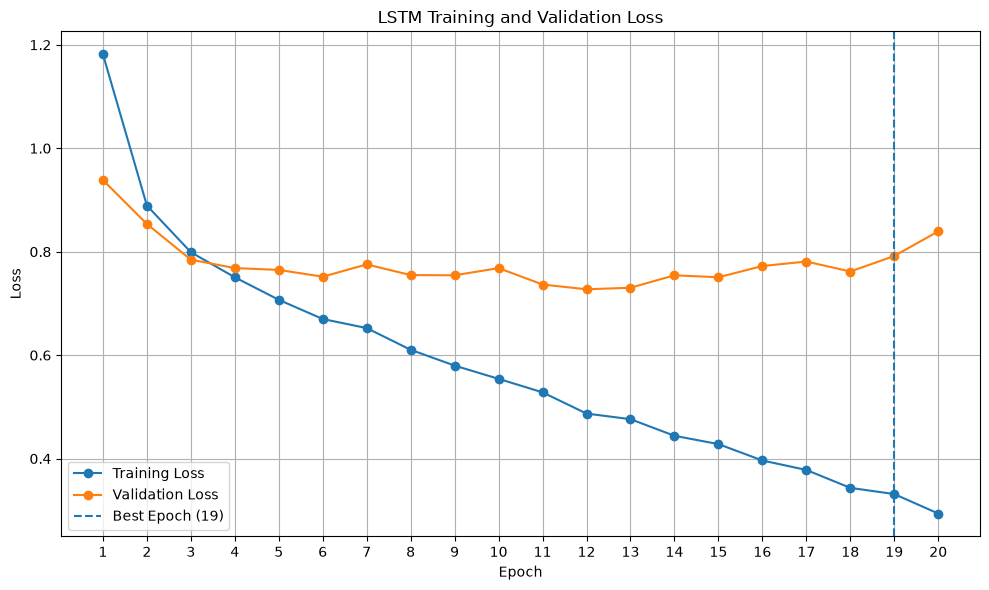

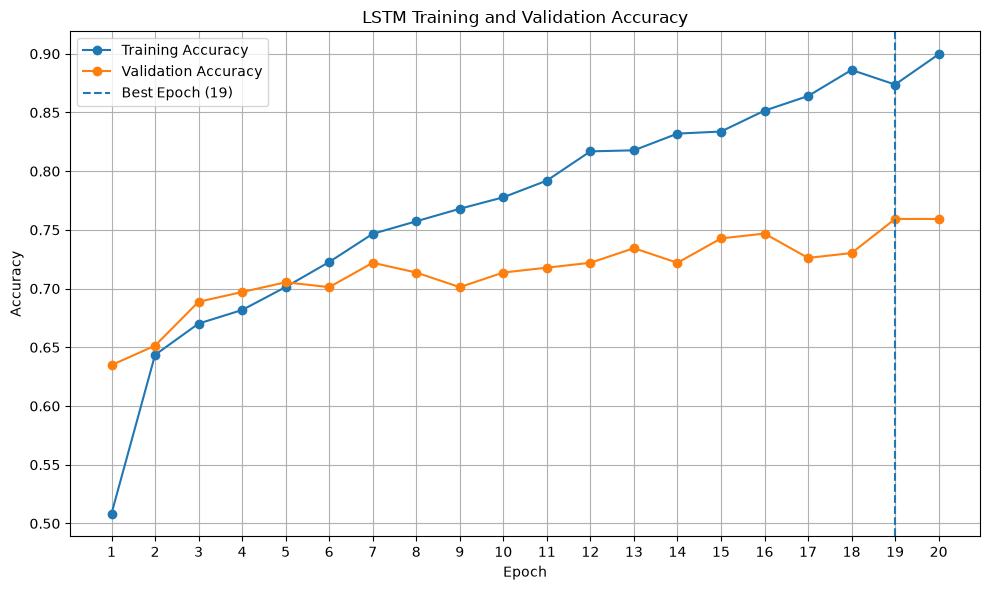

In [49]:
epochs = range(
    1,
    len(lstm_history["train_loss"]) + 1
)

# Plot training and validation loss
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    lstm_history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    lstm_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

# Mark the best validation epoch
plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot training and validation accuracy
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    lstm_history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    lstm_history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

# Mark the best validation epoch
plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The training history shows that the LSTM model learned steadily across the 20 epochs. Training loss decreased from 1.1816 in epoch 1 to 0.2938 in epoch 20, while training accuracy generally increased from 50.84% to 89.96%. Validation accuracy reached its highest value of 75.93% at epochs 19 and 20. Because epoch 19 had the lower validation loss (0.7917 compared with 0.8394), epoch 19 was selected as the best baseline LSTM checkpoint according to the model-selection rule. The lowest validation loss occurred earlier, at epoch 12, while training performance continued to improve afterward. The widening difference between training and validation performance, together with the later increase in validation loss, suggests that the model was beginning to overfit. The epoch 19 checkpoint was retained for later comparison and optimization.

### 8.6 Display the Validation Confusion Matrix

In this step, a confusion matrix is generated to visualize the validation performance of the best baseline LSTM model. The confusion matrix compares the true composer labels with the predicted composer labels for every validation sample. The values along the main diagonal represent correctly classified samples, while the off-diagonal values indicate misclassifications between composers. This visualization helps identify which composers are recognized accurately and which pairs of composers are more difficult for the model to distinguish. The confusion matrix provides a more detailed understanding of the model's classification behavior beyond the overall validation metrics.

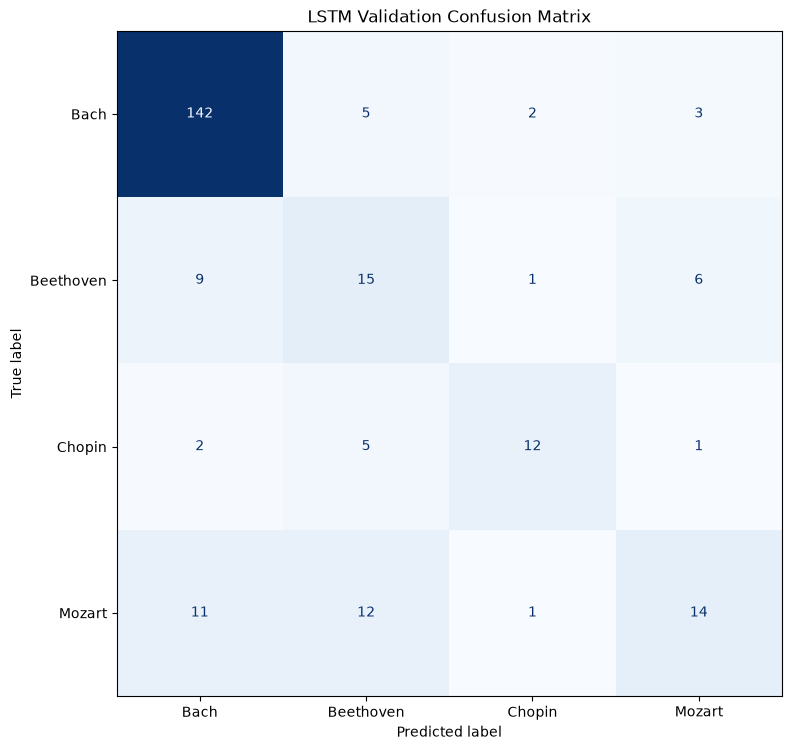

In [50]:
lstm_confusion_matrix = confusion_matrix(
    lstm_val_true_labels,
    lstm_val_predicted_labels
)

plt.figure(figsize=(8, 8))

confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=lstm_confusion_matrix,
    display_labels=composer_names
)

confusion_matrix_display.plot(
    cmap="Blues",
    values_format="d",
    ax=plt.gca(),
    colorbar=False
)

plt.title("LSTM Validation Confusion Matrix")
plt.tight_layout()
plt.show()

### 8.7 Generate the Validation Classification Report

In this step, a classification report is generated to provide a detailed evaluation of the best baseline LSTM model on the validation dataset. Unlike overall accuracy, the classification report summarizes the model's performance for each composer individually. For each composer, the report includes precision, recall, F1-score, and support. Precision measures how often the predicted composer labels are correct, recall measures how many actual samples of each composer are correctly identified, and the F1-score provides a balanced measure of precision and recall. The support value indicates the number of validation samples for each composer. This detailed evaluation helps identify which composers are classified accurately and which composers may require further improvement during hyperparameter tuning.

In [51]:
composer_names = [
    "Bach",
    "Beethoven",
    "Chopin",
    "Mozart"
]

lstm_classification_report = classification_report(
    lstm_val_true_labels,
    lstm_val_predicted_labels,
    target_names=composer_names,
    output_dict=True,
    zero_division=0
)

lstm_classification_report_df = (
    pd.DataFrame(lstm_classification_report)
    .transpose()
)

# Remove the accuracy row because it does not have a normal support value
lstm_classification_report_df.drop(
    index="accuracy",
    inplace=True
)

lstm_classification_report_df.rename(
    index={
        "macro avg": "Macro Average",
        "weighted avg": "Weighted Average"
    },
    inplace=True
)

lstm_classification_report_df["support"] = (
    lstm_classification_report_df["support"]
    .astype(int)
)

metric_columns = [
    "precision",
    "recall",
    "f1-score"
]

lstm_classification_report_df[metric_columns] = (
    lstm_classification_report_df[metric_columns]
    .round(4)
)

# Display the report
print("LSTM Validation Classification Report")
print("------------------------------------------")
print(f"Validation Accuracy: {lstm_val_accuracy:.4f}")
print(f"Number of Validation Samples:  {len(lstm_val_true_labels)}")
print()

display(lstm_classification_report_df)

LSTM Validation Classification Report
------------------------------------------
Validation Accuracy: 0.7593
Number of Validation Samples:  241



,precision,recall,f1-score,support
Bach,0.8659,0.9342,0.8987,152
Beethoven,0.4054,0.4839,0.4412,31
Chopin,0.7500,0.6000,0.6667,20
Mozart,0.5833,0.3684,0.4516,38
Macro Average,0.6511,0.5966,0.6145,241
Weighted Average,0.7525,0.7593,0.7501,241


#### Baseline LSTM Validation Findings

The baseline LSTM achieved a validation accuracy of 75.93% and a weighted F1-score of 0.7501. Performance was strongest for Bach, with an F1-score of 0.8987. Chopin achieved an F1-score of 0.6667, while Beethoven and Mozart had lower F1-scores of 0.4412 and 0.4516, respectively. These results show that the model learned useful composer-specific sequential patterns, but its performance was uneven across the four classes. Because Bach represents the majority of the validation set, the weighted metrics are strongly influenced by the model’s performance on Bach. The lower performance for the minority composers supports testing class-weighted loss and training-only data augmentation during model optimization. These findings are based only on the validation set. The test set remains unused until the final LSTM and CNN configurations have been selected.

## 9. Build, Train, and Validate CNN Model

In this section, a one-dimensional Convolutional Neural Network (1D CNN) is developed to classify the MIDI files as Bach, Beethoven, Chopin, or Mozart.

The CNN uses the same encoded pitch, velocity, note duration, and time-interval sequences used by the LSTM. Encoded pitch values are first passed through an embedding layer. The pitch embeddings are then combined with the continuous musical features.

The combined sequence is passed through one-dimensional convolutional layers. These layers learn local musical patterns, such as short note progressions, rhythmic combinations, and nearby pitch relationships. Pooling layers reduce the sequence length and help the model focus on the most useful patterns.

The CNN is trained using the same training set and monitored using the same validation set as the baseline LSTM. The test set remains unused until final model selection and evaluation.

This section includes:

- **9.1** Define the CNN Model Architecture
- **9.2** Configure the CNN Training Process
- **9.3** Train the CNN Model
- **9.4** Evaluate the CNN Model on the Validation Set
- **9.5** Visualize the CNN Training History
- **9.6** Display the CNN Validation Confusion Matrix
- **9.7** Generate the CNN Validation Classification Report

The CNN’s validation performance will be measured using accuracy, weighted precision, weighted recall, weighted F1-score, a per-class classification report, and a confusion matrix. Its results will later be compared with the baseline LSTM.

## 10. Hyperparameter Tuning and Model Optimization

In this section, we improve model performance by testing different hyperparameter values and training strategies.

The hyperparameters considered may include:

- Learning rate
- Batch size
- Number of epochs
- Number of hidden units
- Number of LSTM layers
- CNN filter sizes
- Dropout rate
- Optimizer type

Additional optimization strategies may include:

- Training-only pitch-shift augmentation
- Training-only time-stretch augmentation
- Class-weighted loss

All configurations will be compared using validation-set performance. The test set will remain untouched until the final LSTM and CNN models have been selected.

## 11. Final Model Evaluation and Comparison

In this section, the final selected LSTM and CNN models will be evaluated on the test set.

The test set has remained unused during baseline training, validation, and hyperparameter tuning. It will be used only after the final model configurations have been selected using validation-set performance. This provides an unbiased estimate of how well each model generalizes to unseen MIDI files.

The final comparison will include:

- Test accuracy
- Weighted precision
- Weighted recall
- Weighted F1-score
- Per-class classification reports
- Test confusion matrices
- Training behavior
- Strengths and weaknesses of each model

The results will be compared to determine which final model performs better for composer classification.

## 12. Conclusions

In this section, we summarize the full project and main findings.

The conclusion should include:

- A brief summary of the project goal
- The preprocessing and feature extraction approach
- The models used
- The best-performing model
- Key findings from the evaluation
- Limitations of the project
- Possible future improvements

This section should clearly explain what was learned from the project.

## 13. References

This section lists all external sources, libraries, frameworks, and datasets used in the project.

References should be written in APA 7 format when possible.

Possible references include:

- Kaggle MIDI classic music dataset
- PyTorch documentation
- scikit-learn documentation
- NumPy documentation
- pandas documentation
- pretty_midi or music21 documentation
- Matplotlib and Seaborn documentation